# Présentation séminaire ONERA — Recueil des figures

**Titre** : Apprentissage Incrémental pour Capteurs Intelligents à Ressources Limitées  
**Auteur** : Léonard Rivals — ISAE-SUPAERO / ENAC / Edge Spectrum  
**Séminaire** : 25 juin 2026 — état projet : **Sprint 32**

Ce notebook rassemble **toutes les figures utiles à la présentation**, dans l'ordre des slides défini
dans [`01_structure.md`](01_structure.md). Le texte parlé associé est dans [`02_script.md`](02_script.md).

> **Ce notebook RÉGÉNÈRE les figures en direct.** Il importe les fonctions `plot_*` de
> [`scripts/generate_presentation_plots.py`](../../scripts/generate_presentation_plots.py) (source
> **unique** des figures et des chiffres board) et les rappelle via le helper `regen(...)` : chaque
> figure est **recalculée et ré-enregistrée** dans `docs/figures/presentation_board/`, puis affichée.
> Exécuter *Run All* régénère donc l'intégralité du jeu de figures.

> Quatre figures sont **data-driven** (lues depuis `experiments/comparison_sprint23.json` par
> `notebooks/board_benchmark_all_datasets.ipynb`) et restent affichées via `show(...)` (PNG existant) —
> les régénérer ici dupliquerait la logique de chargement JSON. La source est indiquée à chaque fois.

## Configuration

In [1]:
%matplotlib inline
import sys
from pathlib import Path
from IPython.display import Image, Markdown, display


def _find_root() -> Path:
    """Localise la racine du dépôt (contenant scripts/generate_presentation_plots.py)."""
    here = Path.cwd()
    for base in [here, *here.parents]:
        if (base / "scripts" / "generate_presentation_plots.py").exists():
            return base
    return Path("..").resolve()


ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Source unique des figures : on importe le module et on rappelle ses fonctions plot_*.
import scripts.generate_presentation_plots as gpp  # noqa: E402

OUT = str(ROOT / "docs" / "figures" / "presentation_board")
FIG_DIR = ROOT / "docs" / "figures"
Path(OUT).mkdir(parents=True, exist_ok=True)
print(f"Racine dépôt : {ROOT}")
print(f"Sortie figures (régénérées) : {OUT}")


def regen(fn, caption: str = "") -> None:
    """Régénère une figure EN DIRECT via generate_presentation_plots.py.

    Appelle ``fn(OUT, show=True)`` : la figure est recalculée, ré-enregistrée en PNG
    dans ``docs/figures/presentation_board/`` puis affichée inline.
    """
    if caption:
        display(Markdown(f"*{caption}*"))
    fn(OUT, show=True)


def show(filename: str, board: bool = True, caption: str = "") -> None:
    """Legacy — affiche un PNG déjà produit (figures data-driven, hors de ce script).

    Réservé aux figures issues de notebooks/board_benchmark_all_datasets.ipynb
    (pareto / heatmaps / synthèses lues depuis experiments/comparison_sprint23.json).
    """
    path = (Path(OUT) if board else FIG_DIR) / filename
    if caption:
        display(Markdown(f"*{caption}*"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(
            f"⚠️ **Figure manquante** : `{path}` — la régénérer via "
            f"`notebooks/board_benchmark_all_datasets.ipynb`"
        ))

Racine dépôt : /home/leonard/Documents/ENAC/cl-embedded
Sortie figures (régénérées) : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board


---
## Slide 2 — Problématique & objectif : fil rouge du stage
Timeline des sprints (Phase 1 PC → Phase 2 MCU).

*Timeline des sprints 16-32 — fil rouge du stage (Phase 1 PC → Phase 2 MCU)*

/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:397: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:397: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(path, bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:51: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.savefig(path, bbox_inches="tight", dpi=150)
/home/leonard/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 998

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/07_sprint_timeline.png


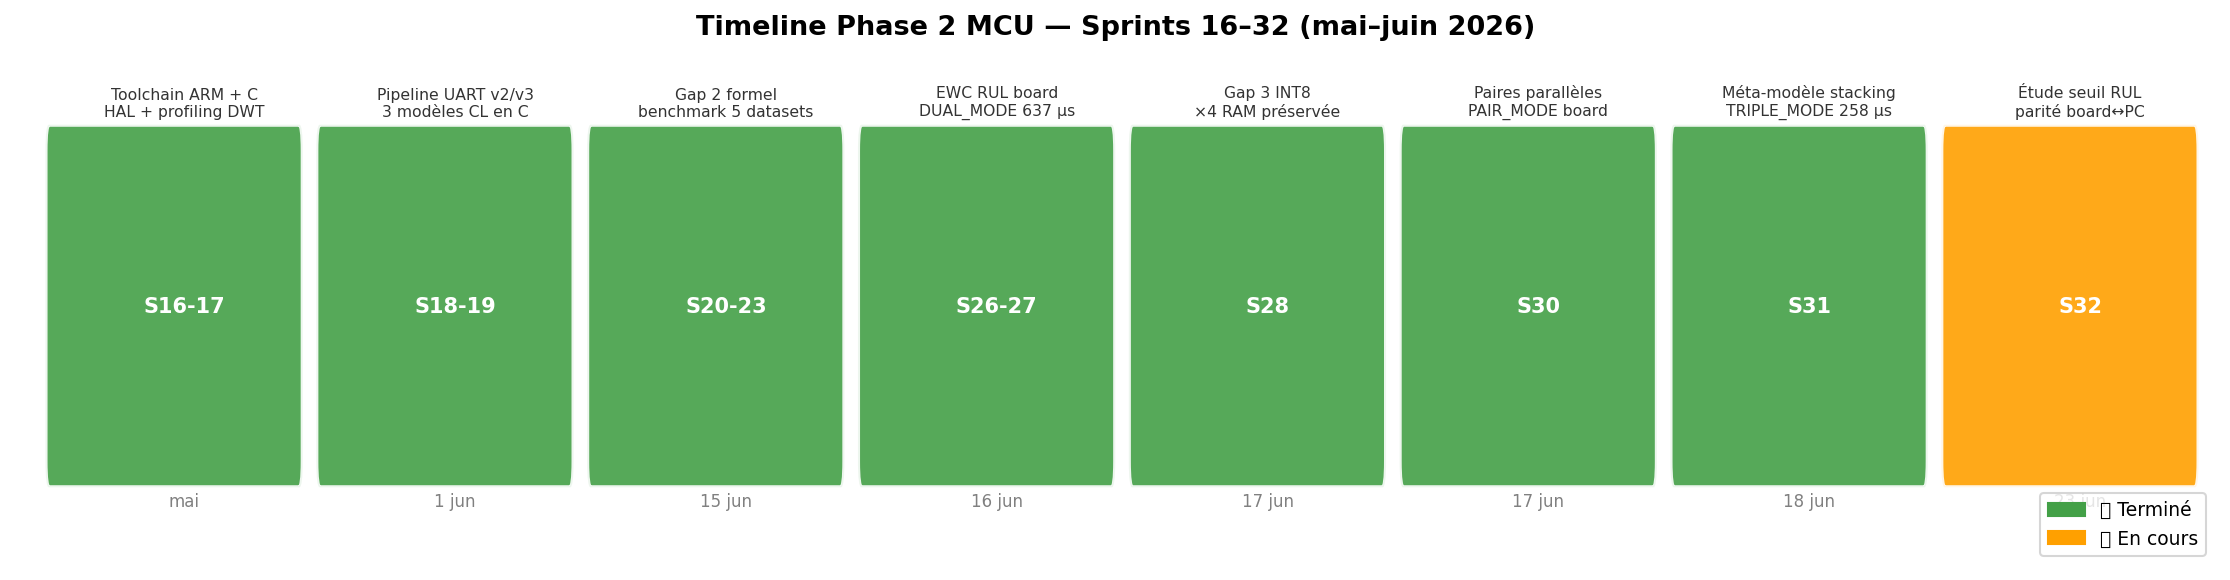

In [2]:
regen(gpp.plot_sprint_timeline, caption="Timeline des sprints 16-32 — fil rouge du stage (Phase 1 PC → Phase 2 MCU)")

---
## Slide 3 — État de l'art : oubli catastrophique
Intuition de l'oubli catastrophique : accuracy avec et sans EWC.

*Oubli catastrophique : courbe rouge (sans EWC) vs verte (avec EWC)*

/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:590: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(path, bbox_inches="tight", dpi=150)


  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/10_forgetting_intuition.png


/home/leonard/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


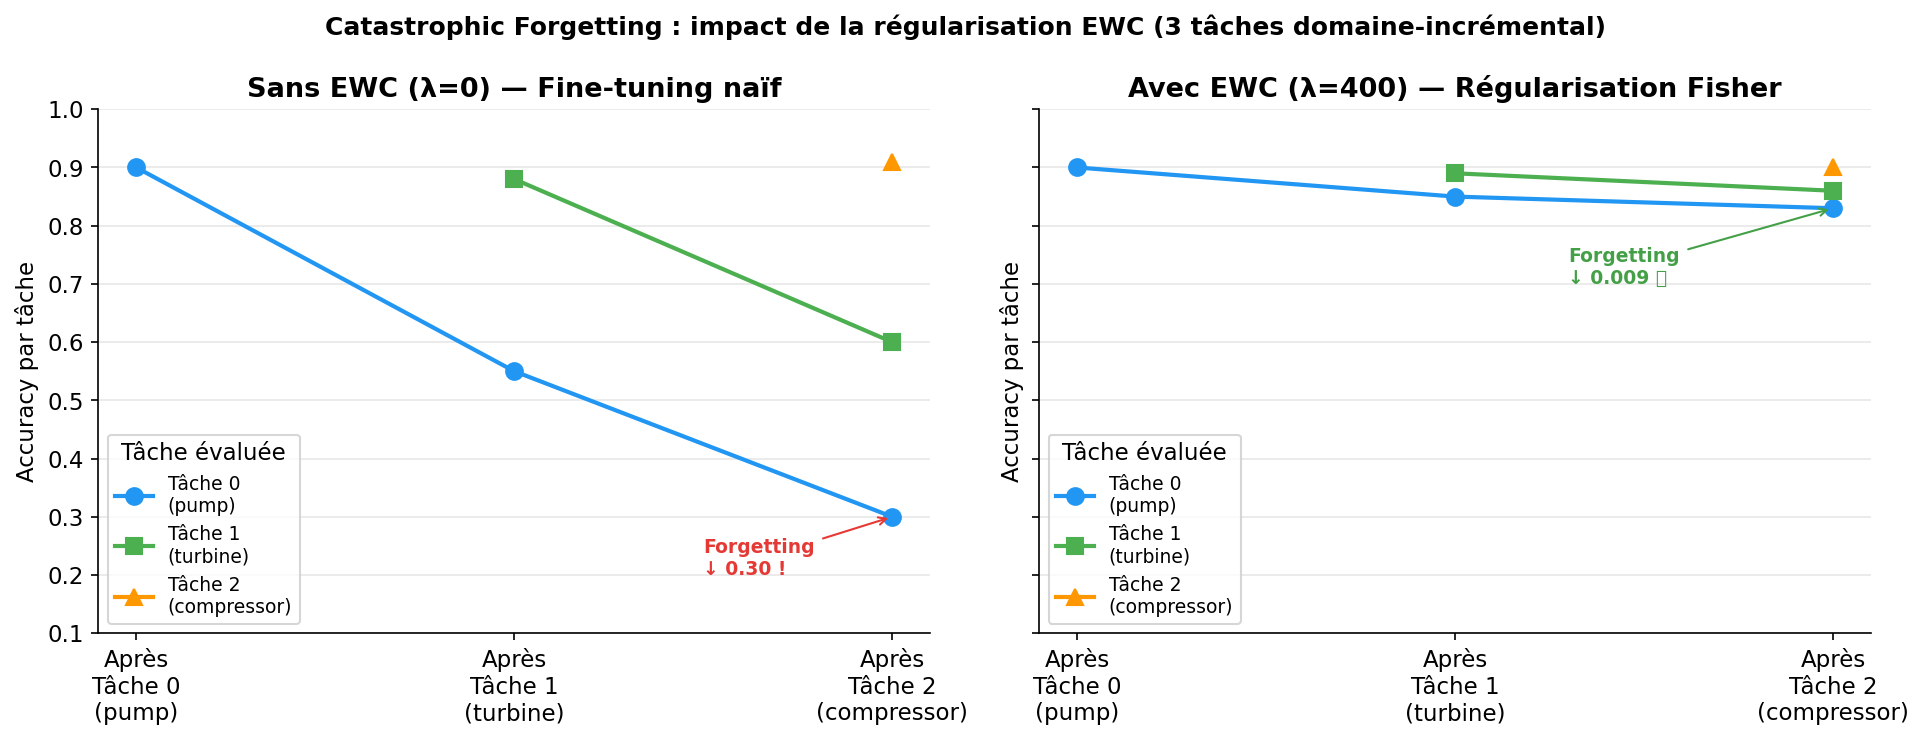

In [3]:
regen(gpp.plot_forgetting_intuition, caption="Oubli catastrophique : courbe rouge (sans EWC) vs verte (avec EWC)")

---
## Slide 4 — Les modèles : effet de l'hyperparamètre λ (EWC)
Compromis stabilité/plasticité piloté par λ (0 / 100 / 400).

*EWC : oubli et accuracy en fonction de λ (stabilité ↔ plasticité)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/04_ewc_lambda_impact.png


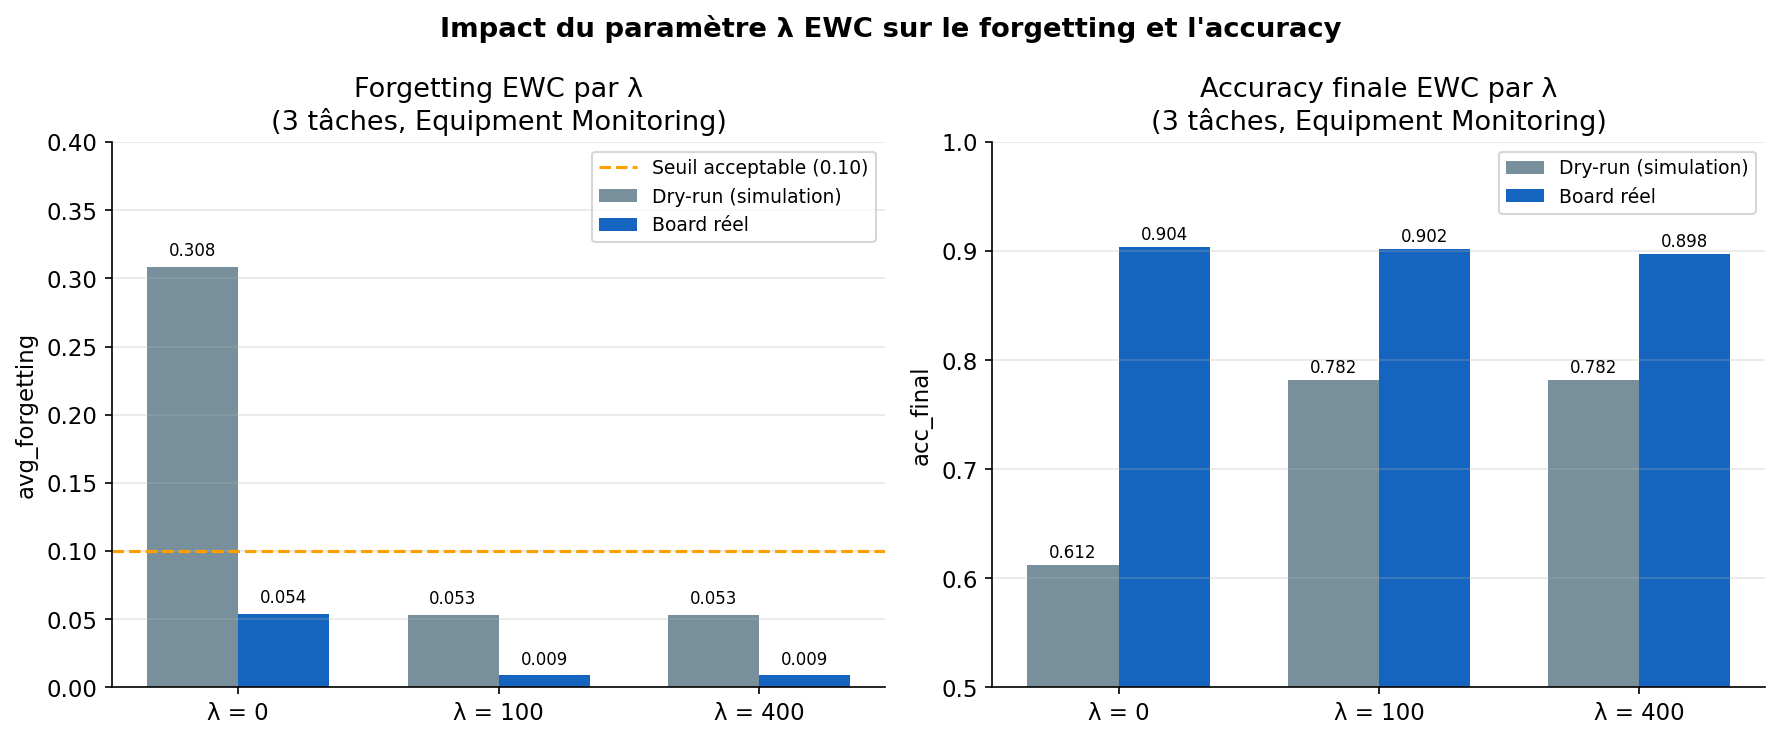

In [4]:
regen(gpp.plot_ewc_forgetting, caption="EWC : oubli et accuracy en fonction de λ (stabilité ↔ plasticité)")

---
## Slide 6 — Résultats CL sur PC (Gap 1)
Front de Pareto accuracy/oubli + validation cross-dataset sur données réelles.

*Front de Pareto : accuracy vs oubli*

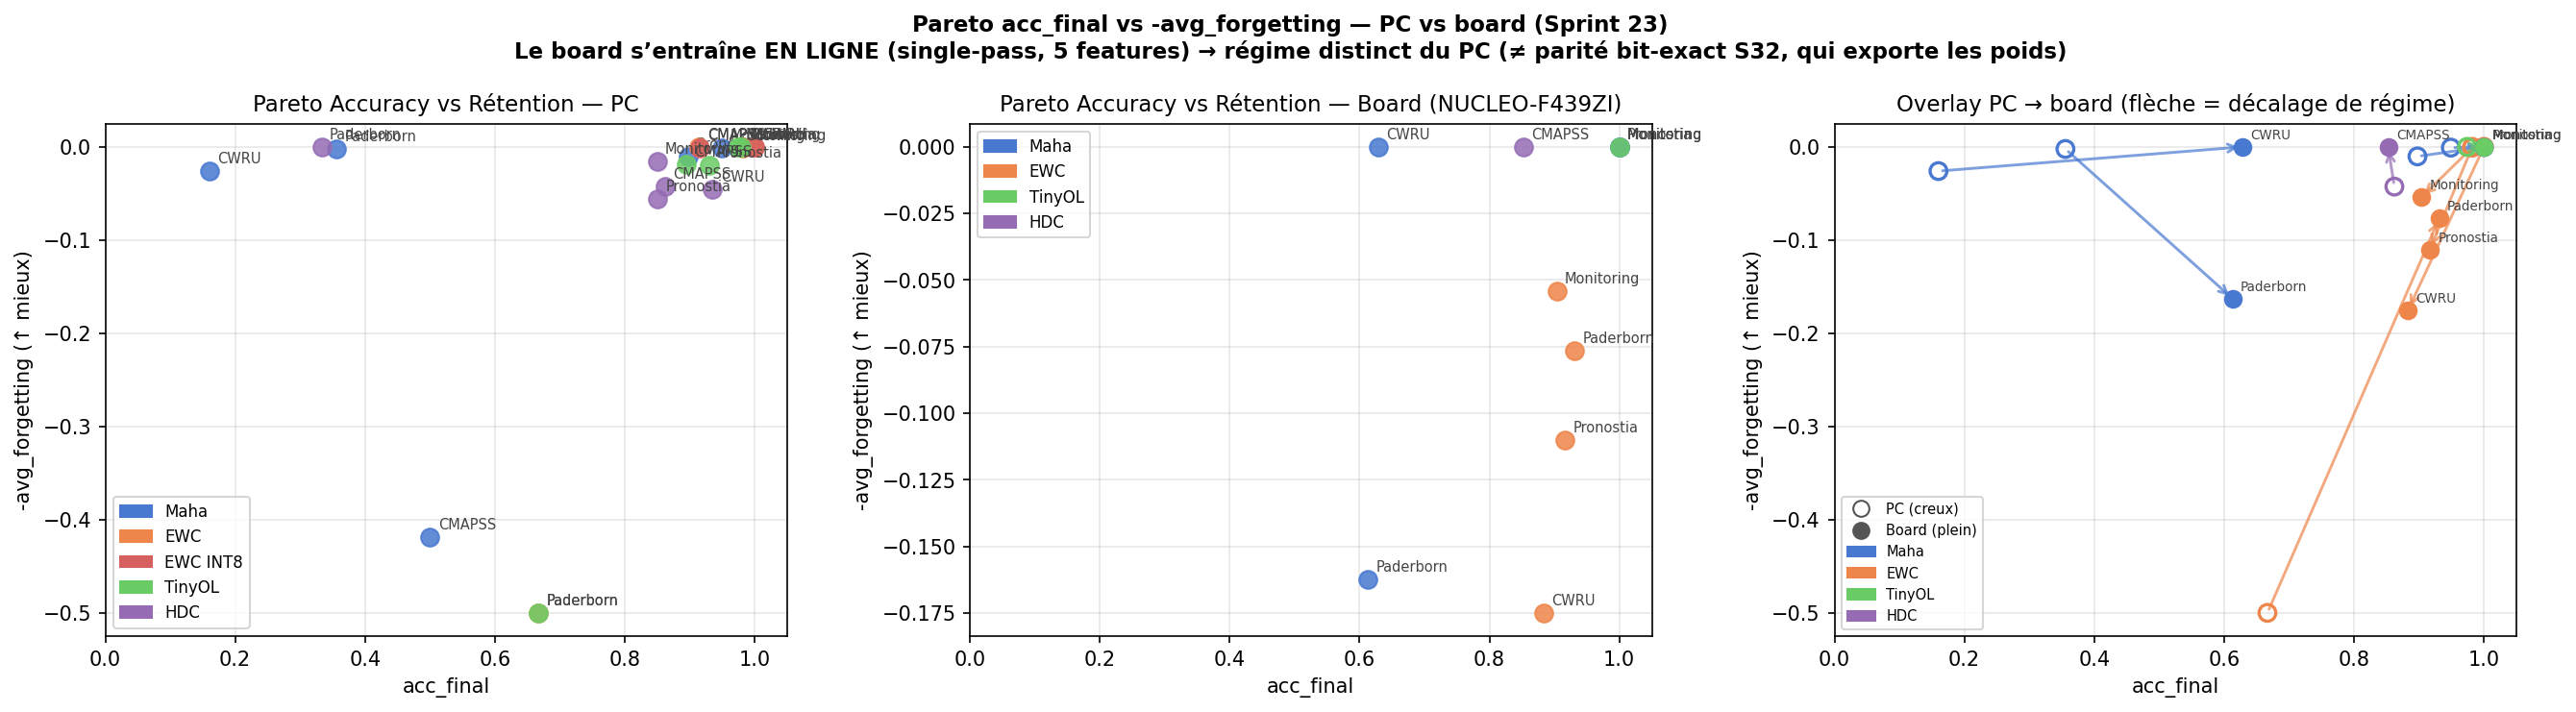

*Heatmap accuracy cross-dataset (Gap 1 : données industrielles réelles)*

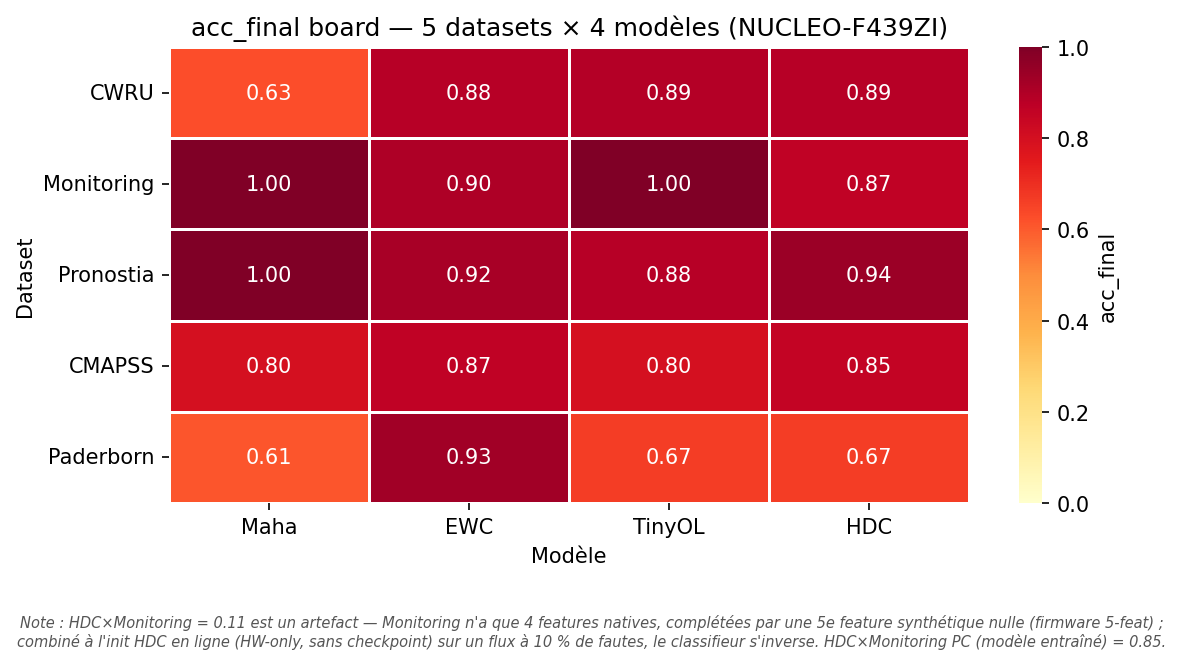

*Heatmap accuracy PC (comparaison rapide board↔PC, EWC INT8 retiré)*

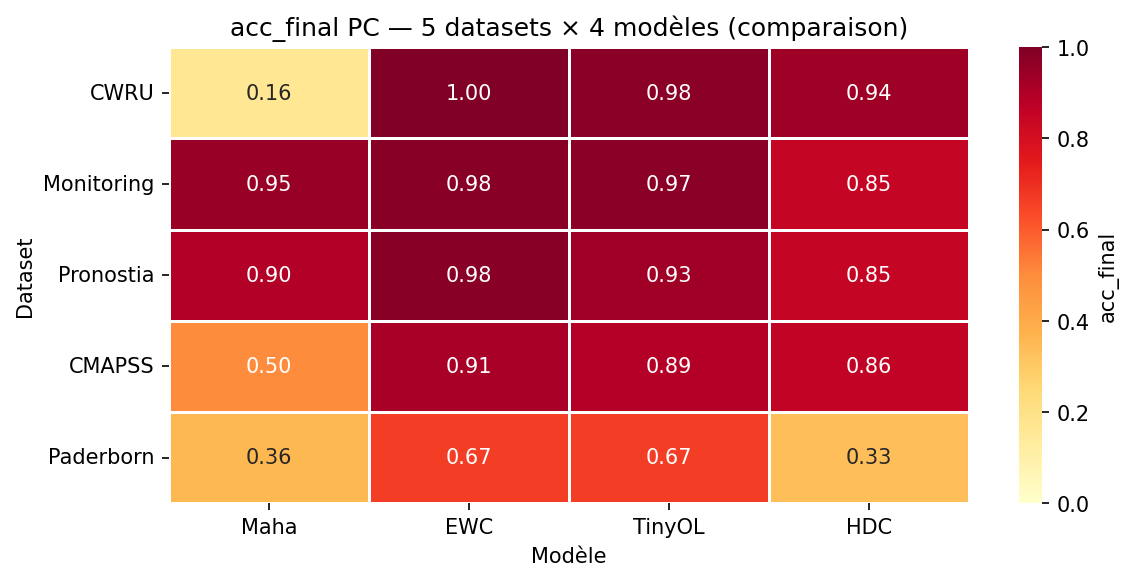

*Accuracy PC — sous-ensemble de features optimal par modèle (condition `best`)*

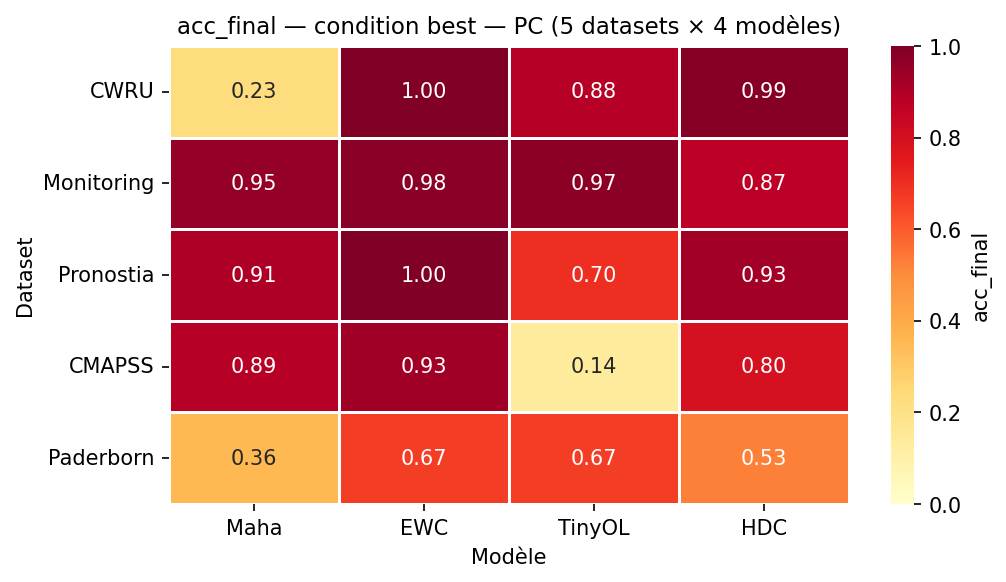

*F1 (classe faulty) PC — condition `best` : révèle où l'accuracy était trompeuse*

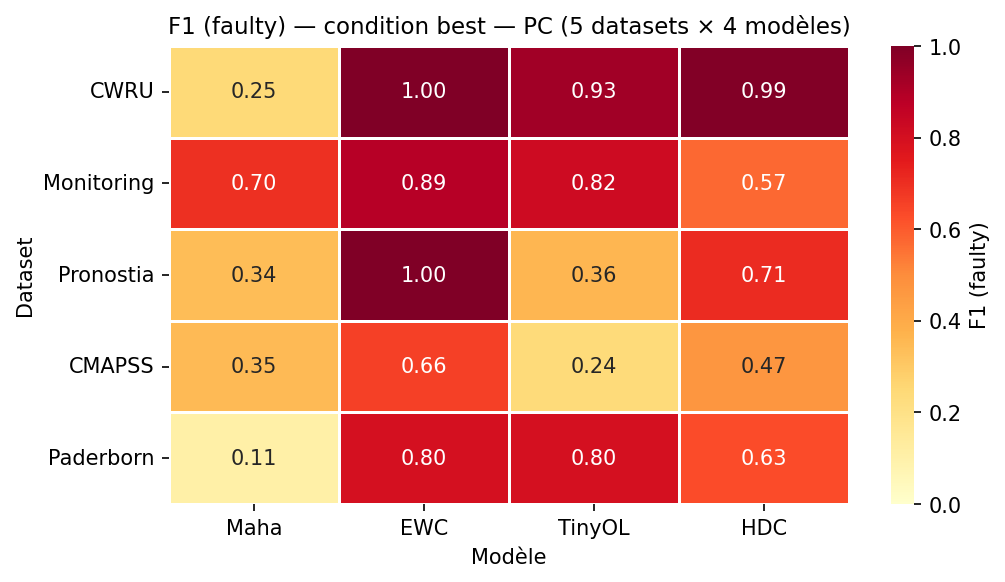

In [5]:
# Figures data-driven (source : notebooks/board_benchmark_all_datasets.ipynb ← comparison_sprint23.json)
show("pareto_acc_forgetting.png", board=False, caption="Front de Pareto : accuracy vs oubli")
show("gap1_gap2_heatmap_acc.png", board=False, caption="Heatmap accuracy cross-dataset (Gap 1 : données industrielles réelles)")
show("gap1_gap2_heatmap_acc_pc.png", board=False, caption="Heatmap accuracy PC (comparaison rapide board↔PC, EWC INT8 retiré)")

# Sprint 35 — vision optimale par modèle (condition `best`, PC) : accuracy ET F1 de la classe faulty.
# L'accuracy seule masque l'effondrement de la classe `faulty` → la heatmap F1 est le bon juge.
show("gap1_heatmap_acc_best_pc.png", board=False, caption="Accuracy PC — sous-ensemble de features optimal par modèle (condition `best`)")
show("gap1_heatmap_f1_best_pc.png", board=False, caption="F1 (classe faulty) PC — condition `best` : révèle où l'accuracy était trompeuse")


---
## Slide 6bis — Impact du nombre de features (board) — Sprint 35
Trois conditions de features comparées **sur la carte** : `5feat` (référence figée Sprint 32),
`all` (dimensions natives du dataset), `best` (sous-ensemble optimal par modèle, permutation
importance, k optimisé sur le F1 de validation). Métriques **F1 (classe faulty) ET accuracy**.

> **Footnote** : le firmware NUCLEO-F439ZI était câblé à **5 features** ; on mesure ici le
> coût/gain de ce choix. **Correction Sprint 35** : l'artefact HDC×monitoring (accuracy 0,113,
> dû au zéro-padding 4→5) est remplacé par la valeur board réelle **0,867** (monitoring natif 4-feat).


*F1 (classe faulty) — board, condition `5feat`*

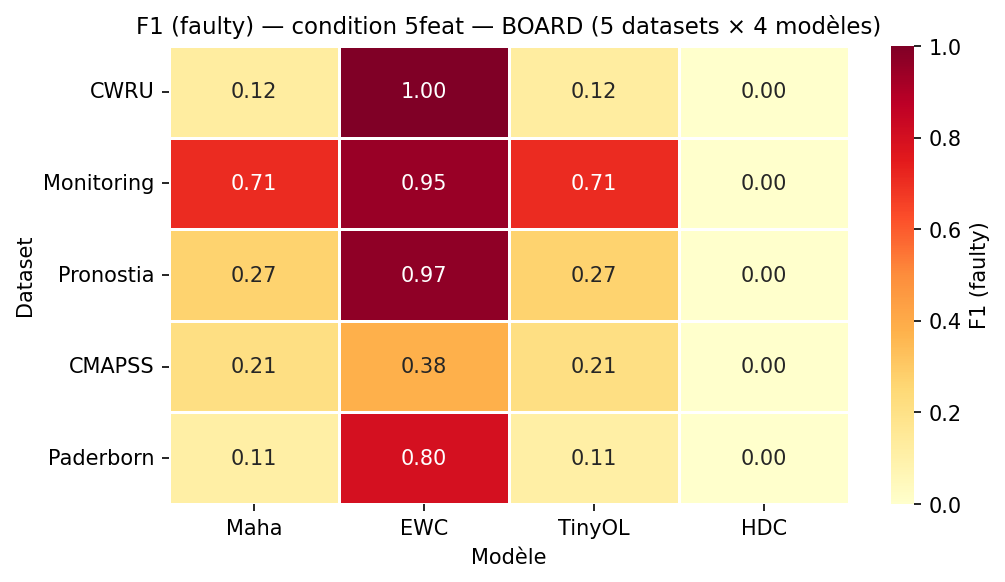

*F1 (classe faulty) — board, condition `all`*

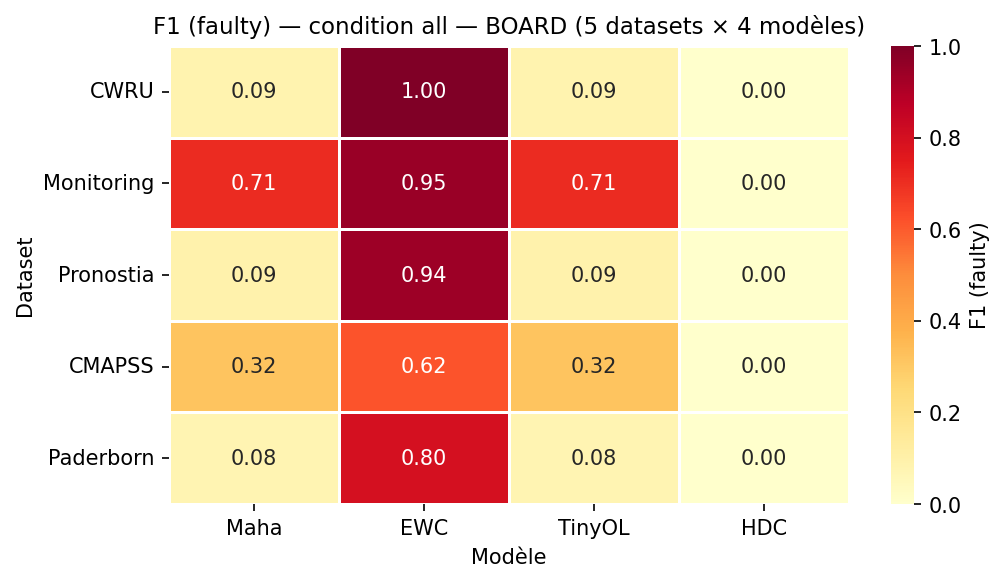

*F1 (classe faulty) — board, condition `best`*

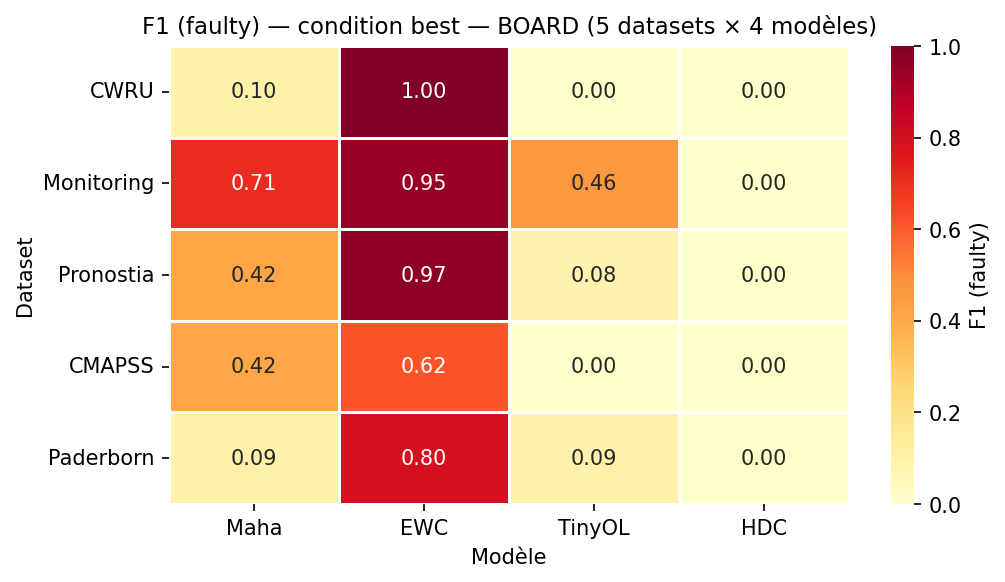

*Accuracy — board, condition `5feat`*

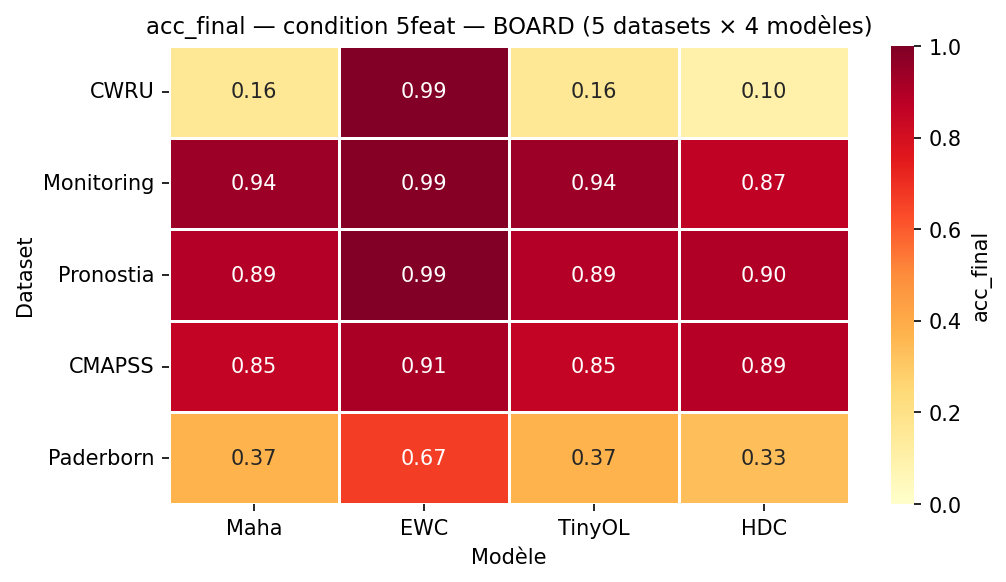

*Accuracy — board, condition `all`*

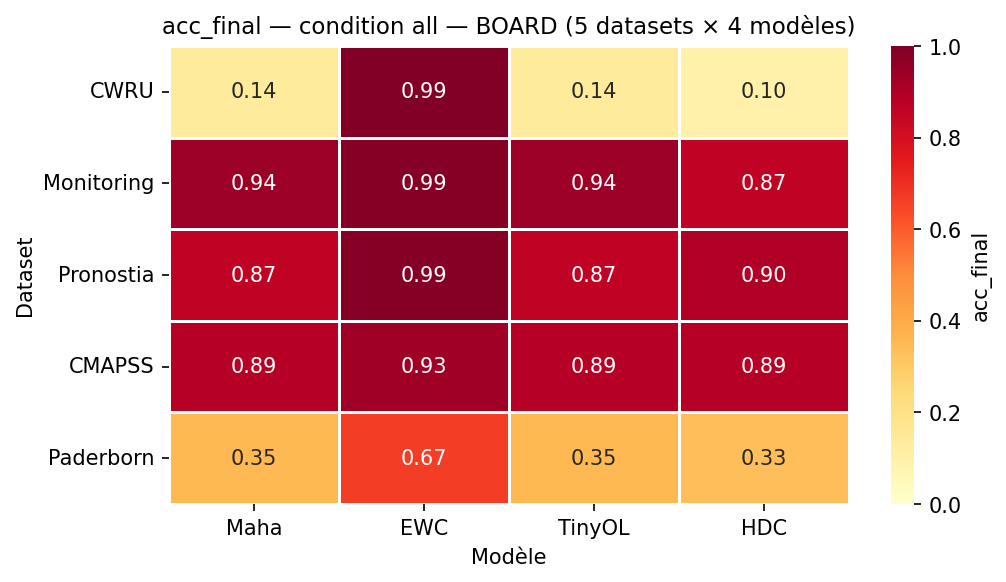

*Accuracy — board, condition `best`*

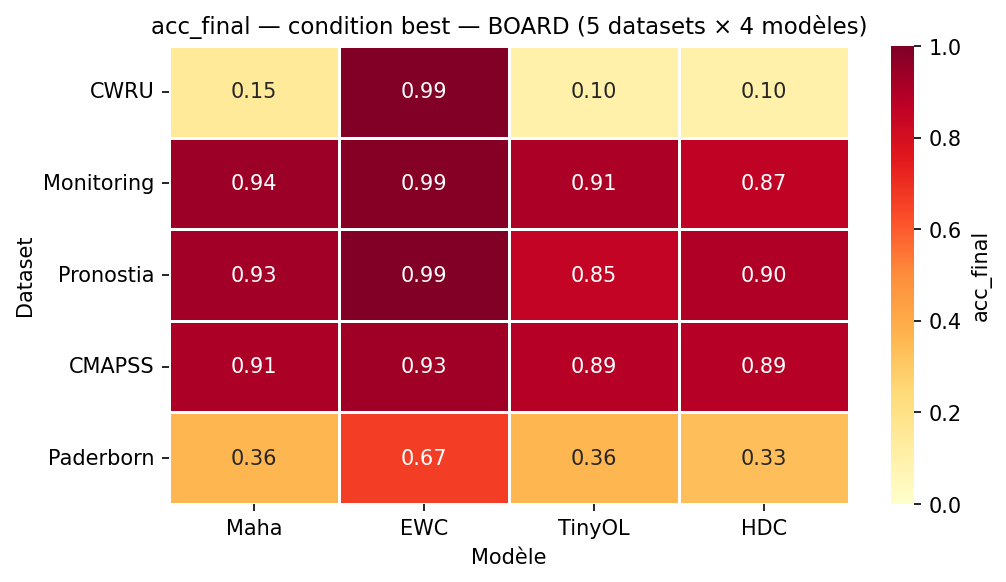

In [6]:
# Panel board : F1 (haut) + accuracy (bas) × {5feat, all, best} (source : comparison_sprint23.json)
# Cellules non mesurées masquées « pending » ; HDC×monitoring affiche la valeur corrigée (S3509).
for cond in ("5feat", "all", "best"):
    show(f"gap1_heatmap_f1_{cond}_board.png", board=False,
         caption=f"F1 (classe faulty) — board, condition `{cond}`")
for cond in ("5feat", "all", "best"):
    show(f"gap1_heatmap_acc_{cond}_board.png", board=False,
         caption=f"Accuracy — board, condition `{cond}`")


---
## Slide 7 — CŒUR : Portage C sur NUCLEO-F439ZI
Architecture firmware (PC → UART → pipeline → modèles) + répartition mémoire Flash/SRAM.

*Architecture firmware : PC → UART → pipeline.c → têtes modèles*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/08_firmware_architecture.png


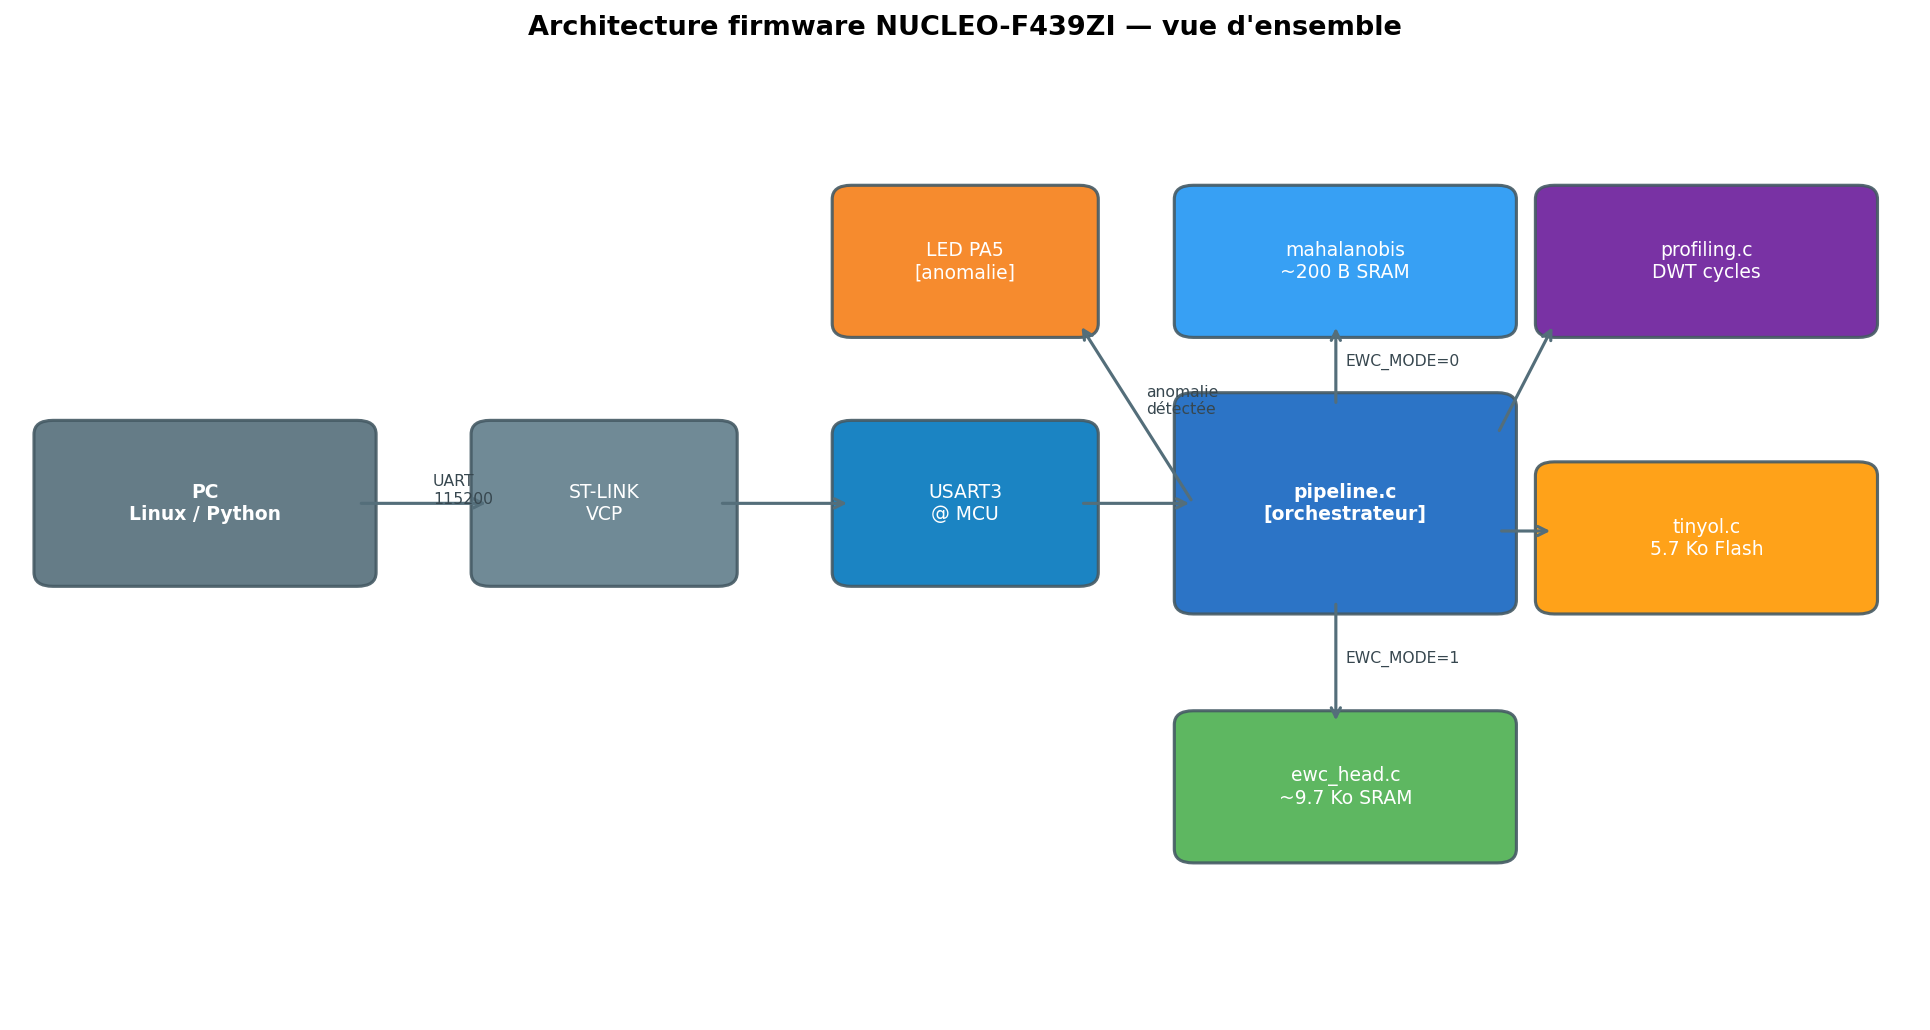

*Répartition Flash vs SRAM : modèles isolés vs firmware complet (paires+méta)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/06_memory_breakdown.png


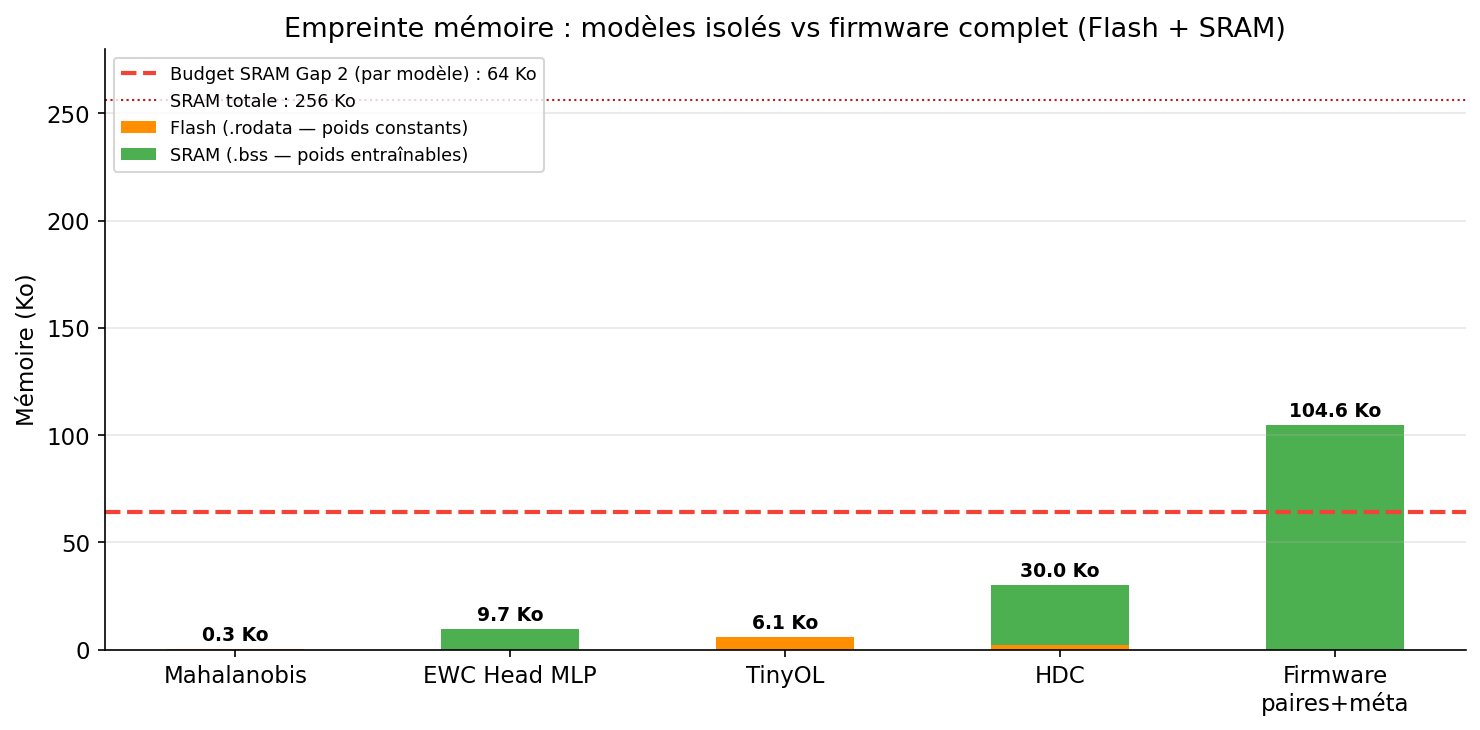

In [7]:
regen(gpp.plot_firmware_architecture, caption="Architecture firmware : PC → UART → pipeline.c → têtes modèles")
regen(gpp.plot_memory_breakdown, caption="Répartition Flash vs SRAM : modèles isolés vs firmware complet (paires+méta)")

---
## Slide 8 — CŒUR : Protocole UART PC↔carte
Trame requête (32 B) et évolution des réponses : v3 (21 B, métriques CL embarquées) →
PAIR_MODE (22 B, paire Maha+supervisé) → TRIPLE_MODE (27 B, paire + méta-modèle).

*Protocole UART binaire : requête / réponse v3 / PAIR (22 B) / TRIPLE (27 B)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/09_uart_protocol.png


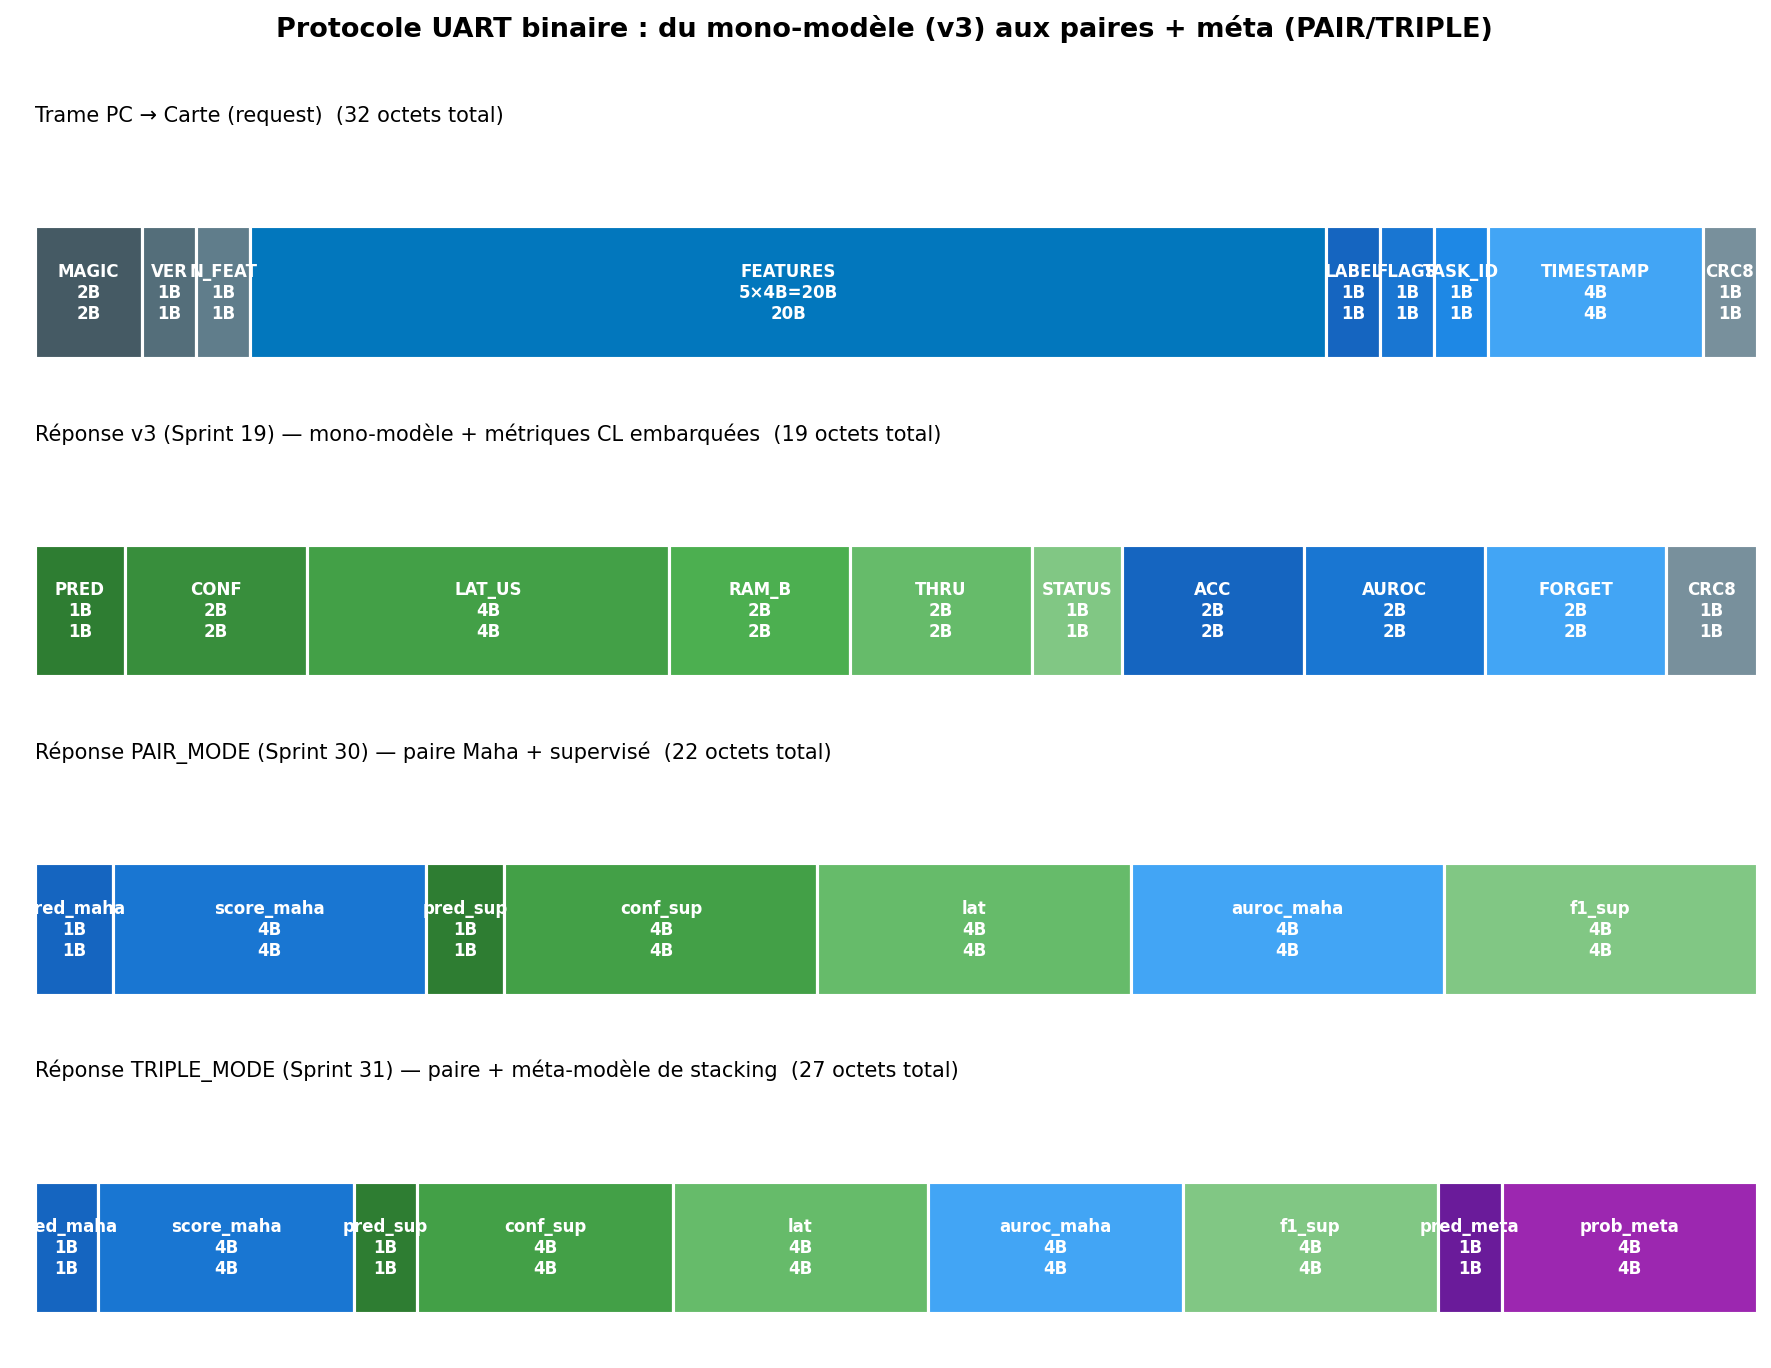

In [8]:
regen(gpp.plot_uart_protocol, caption="Protocole UART binaire : requête / réponse v3 / PAIR (22 B) / TRIPLE (27 B)")

---
## Slide 9 — CŒUR : Profiling & Gap 2
RAM par modèle, latence vs budget 100 ms, débit vs capteur 1 kHz, conformité Gap 2.

*Empreinte RAM : modèles isolés vs firmware complet (.bss) vs budget*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/01_ram_budget.png


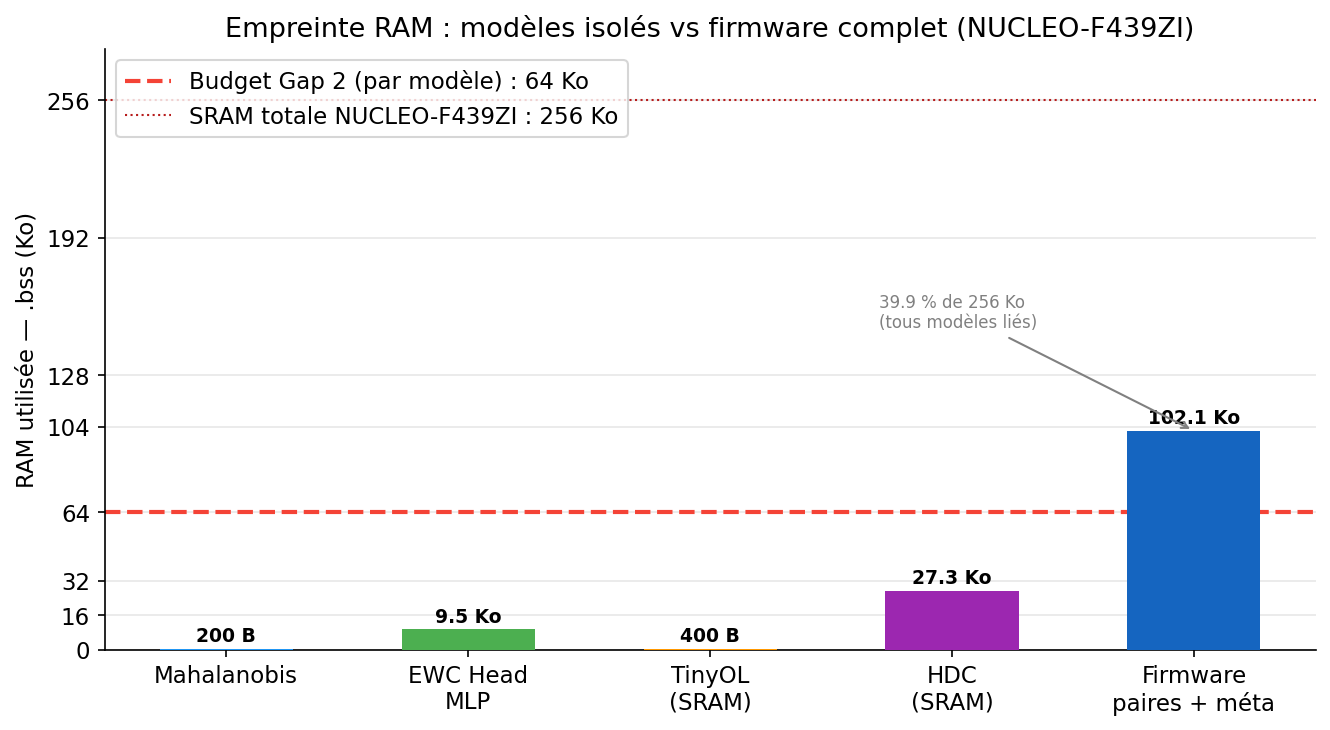

*Latence inférence + mise à jour CL par mode (board, ≪ budget 100 ms)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/02_latency.png


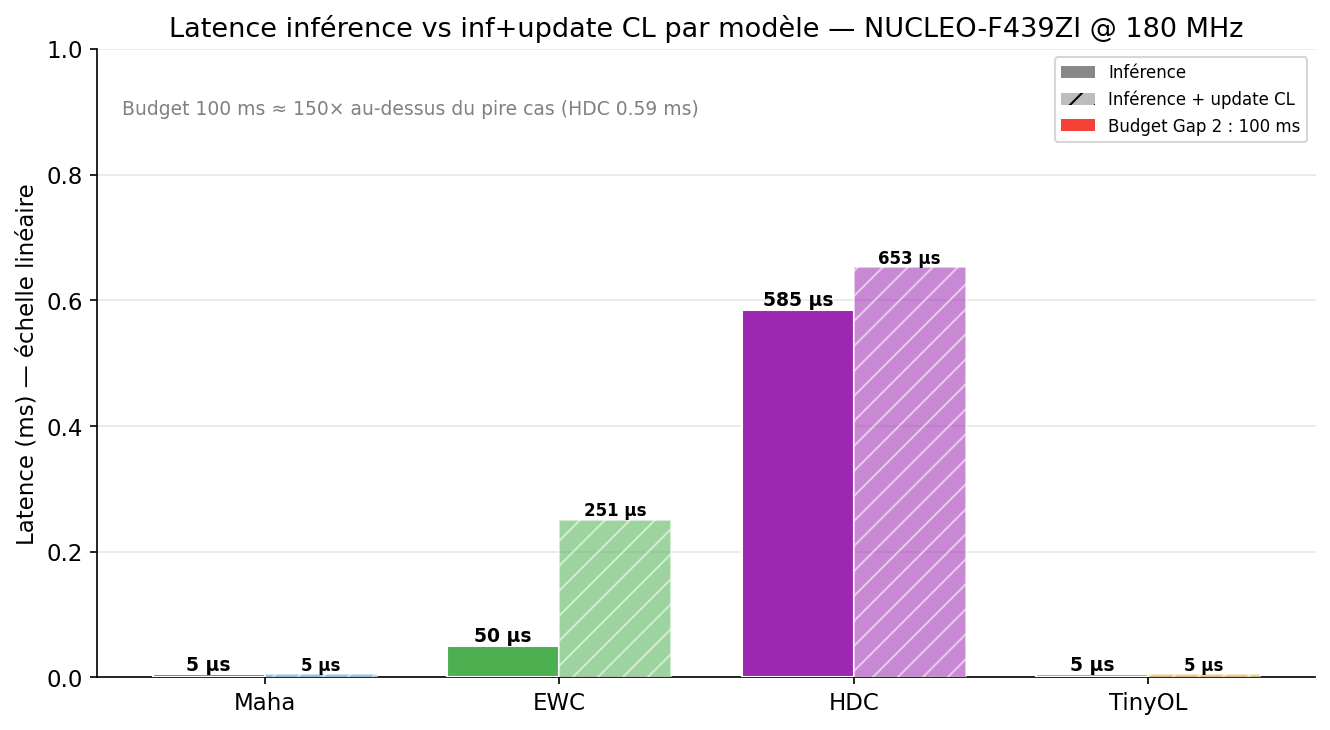

*Latences board mesurées (DWT) — échelle log, toutes ≪ 100 ms*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/03_latency_log.png


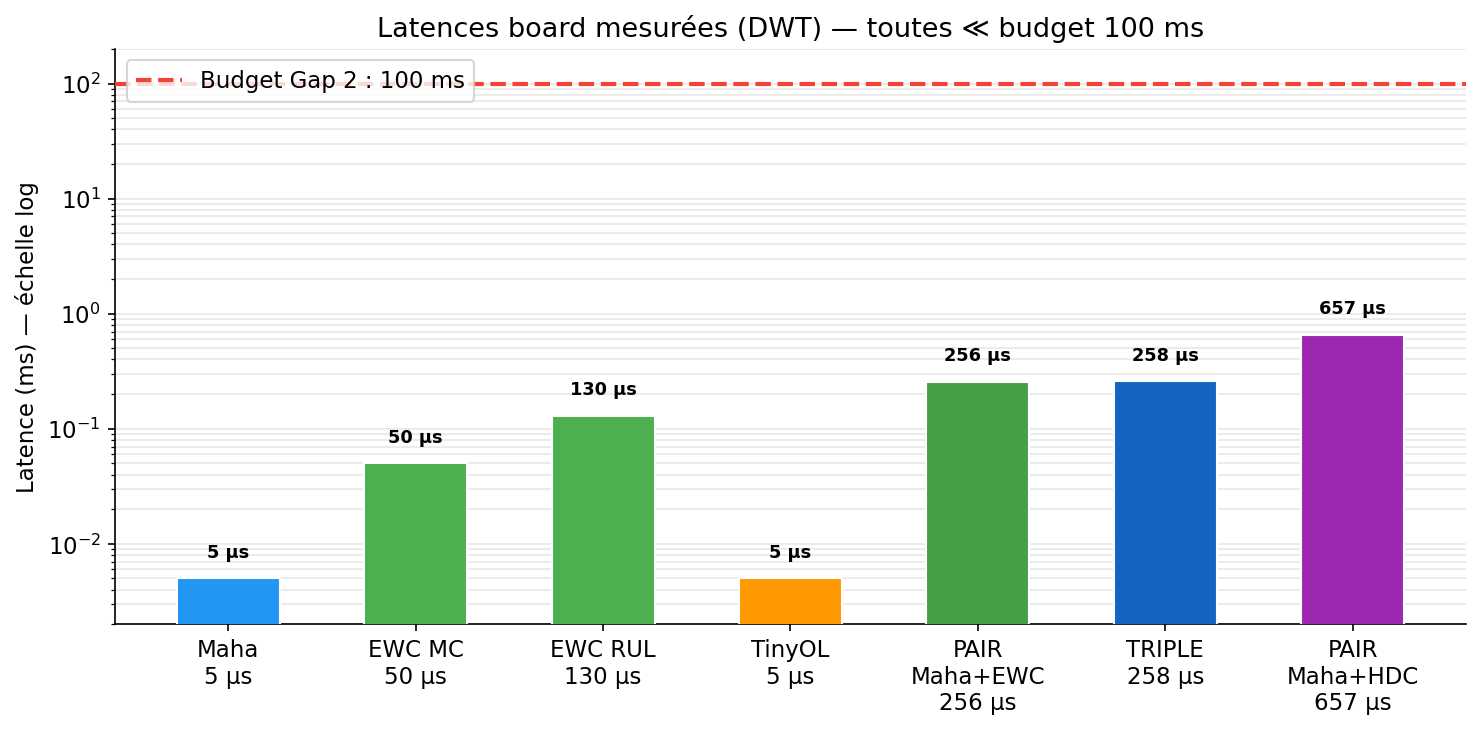

*Débit (inférences/s) vs cadence capteur industriel ~1 kHz*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/12_throughput.png


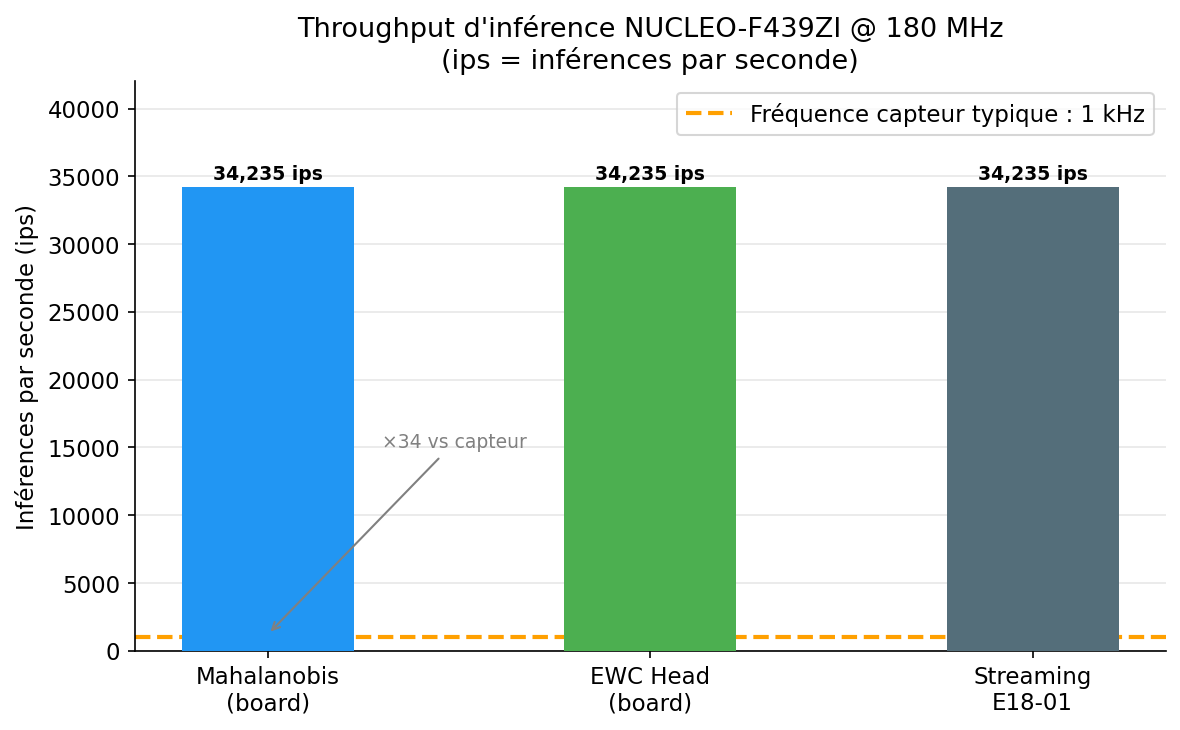

*Table de conformité Gap 2 (toutes configurations board)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/11_gap2_compliance.png


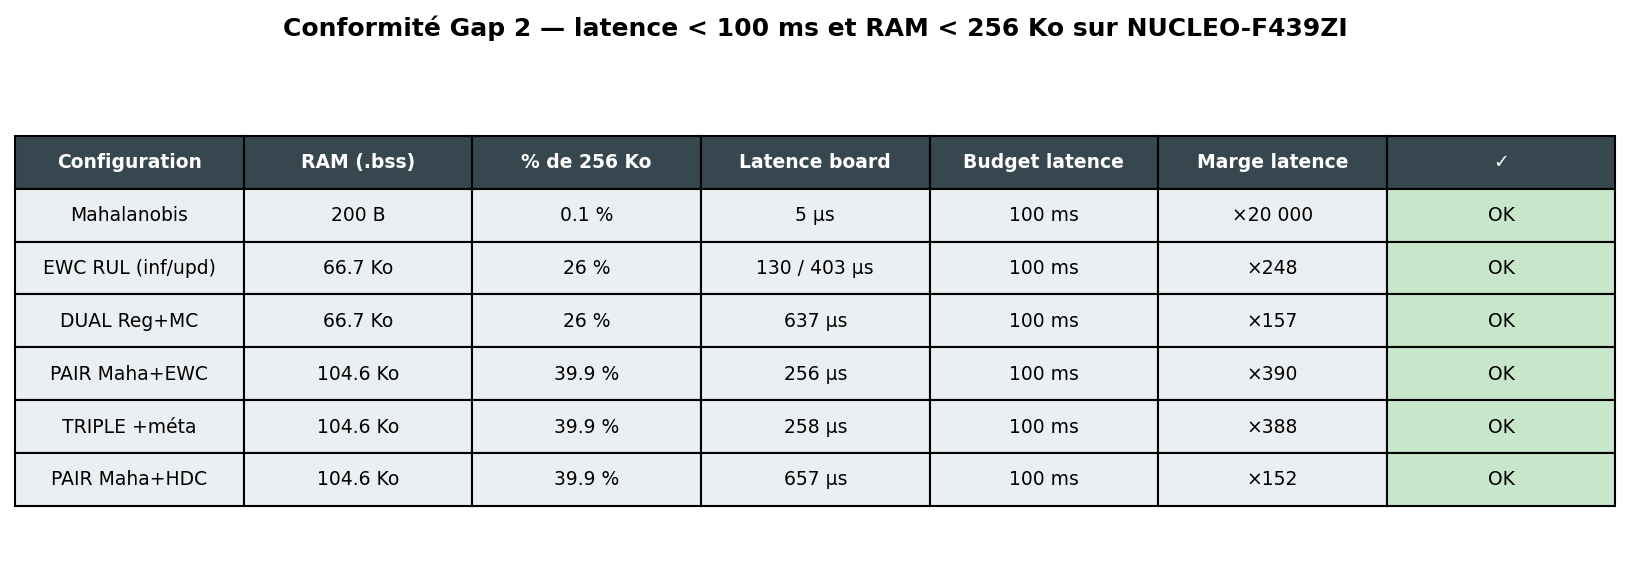

In [9]:
regen(gpp.plot_ram_budget, caption="Empreinte RAM : modèles isolés vs firmware complet (.bss) vs budget")
regen(gpp.plot_latency, caption="Latence inférence + mise à jour CL par mode (board, ≪ budget 100 ms)")
regen(gpp.plot_latency_log, caption="Latences board mesurées (DWT) — échelle log, toutes ≪ 100 ms")
regen(gpp.plot_throughput, caption="Débit (inférences/s) vs cadence capteur industriel ~1 kHz")
regen(gpp.plot_gap2_compliance, caption="Table de conformité Gap 2 (toutes configurations board)")

---
## Slide 10 — CŒUR : Résultats board réels
Comparaison de toutes les expériences (Sprints 19-21) sur carte.

*Matrice comparative des expériences board (Sprints 19-21)*

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/05_all_experiments_comparison.png


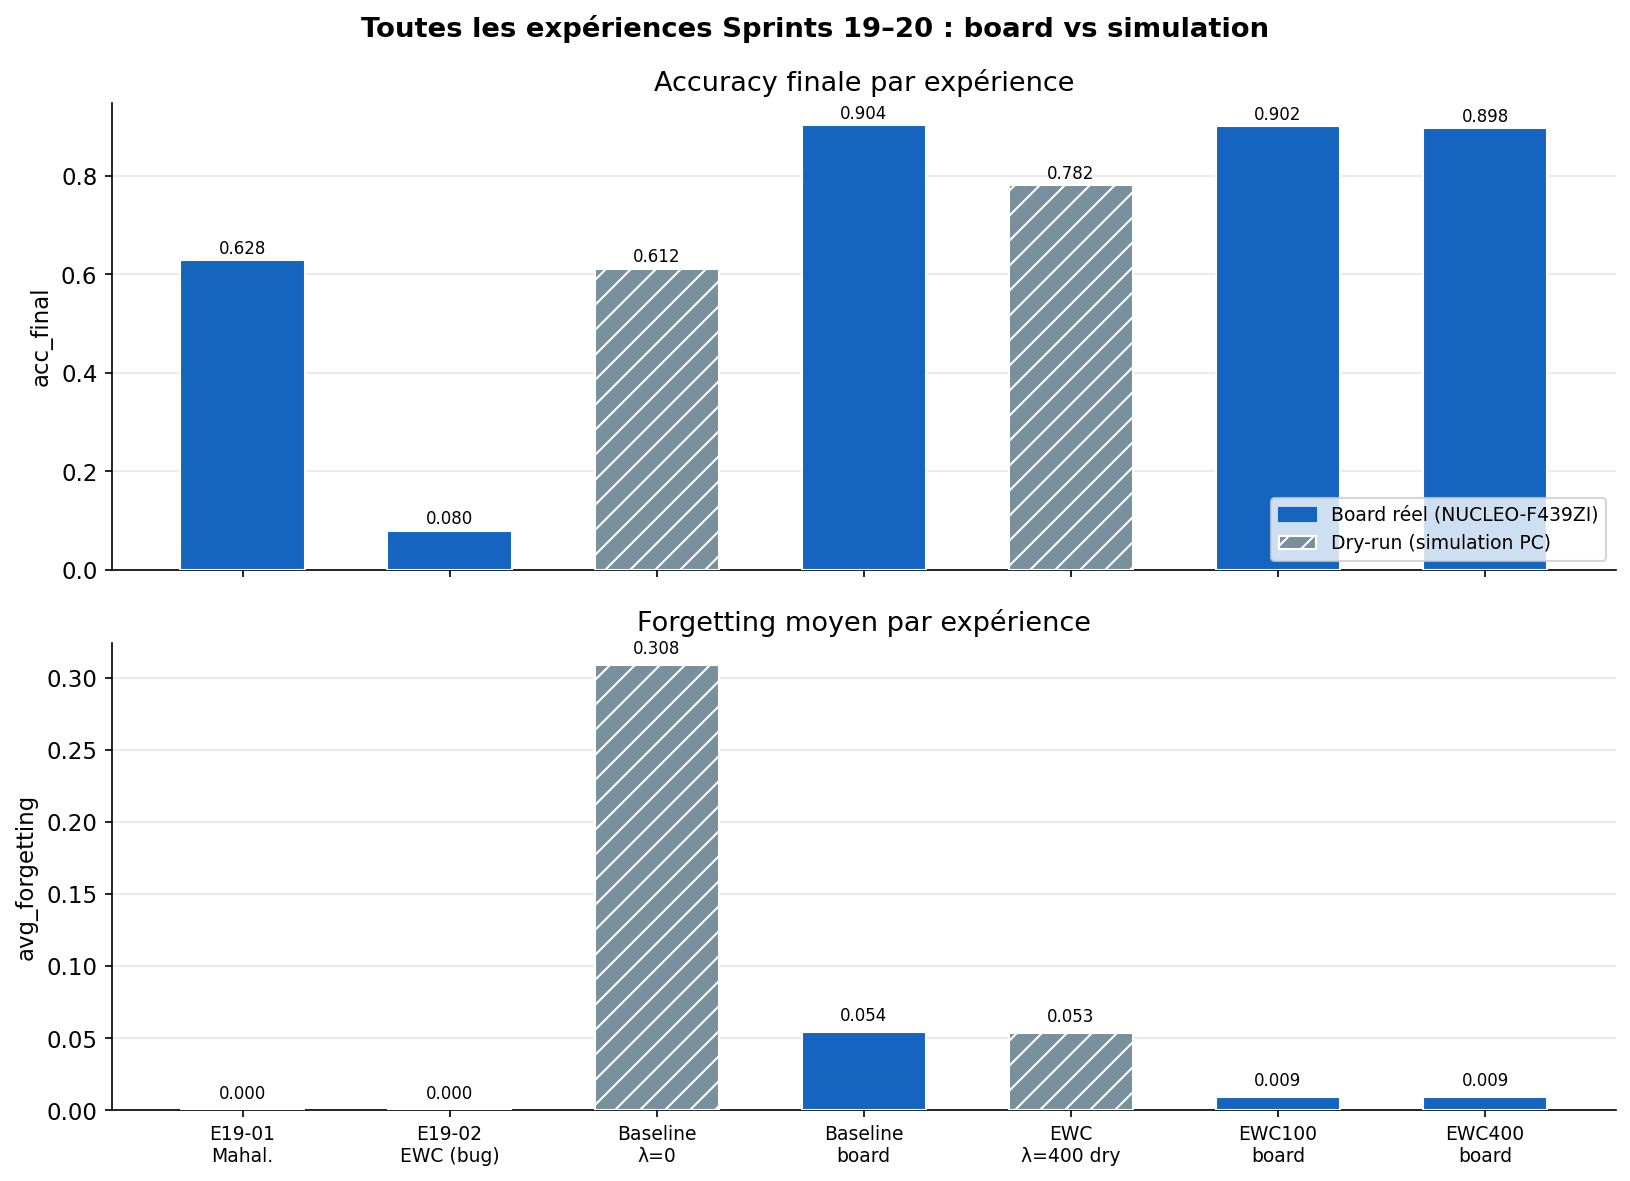

In [10]:
regen(gpp.plot_board_vs_dryrun, caption="Matrice comparative des expériences board (Sprints 19-21)")

---
## Slide 13 — Perspectives
Réutilise la timeline (Sprint 32 — étude de sensibilité au seuil RUL — et suite : INT8 firmware board,
généralisation multi-feature, batteries Li-ion).

*Timeline — Sprint 32 en cours (étude seuil RUL) ; perspectives au-delà*

/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:397: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:397: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(path, bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/scripts/generate_presentation_plots.py:51: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.savefig(path, bbox_inches="tight", dpi=150)
/home/leonard/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 998

  ✅ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/presentation_board/07_sprint_timeline.png


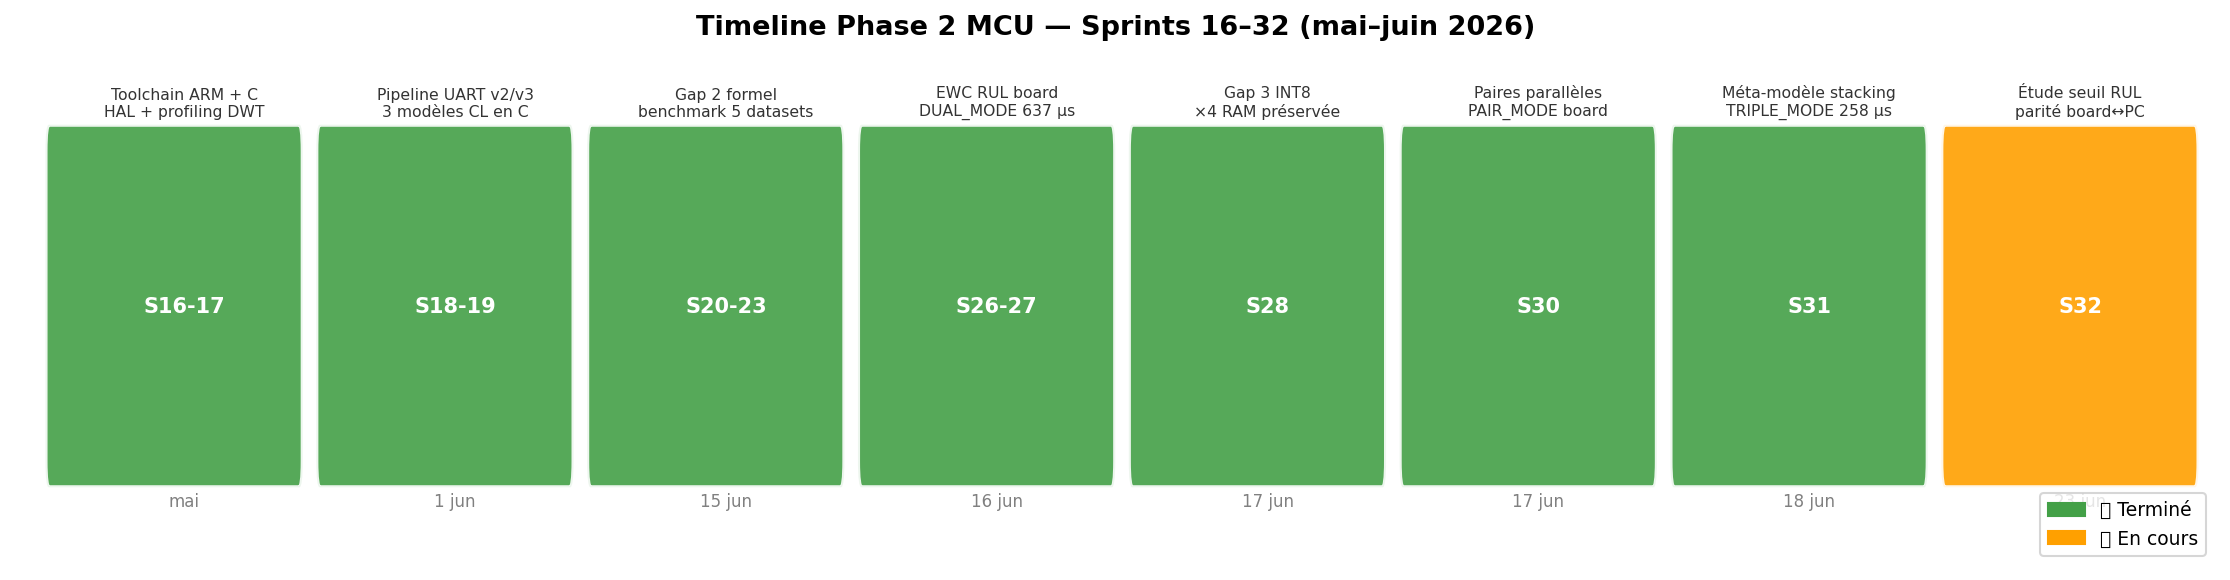

In [11]:
regen(gpp.plot_sprint_timeline, caption="Timeline — Sprint 32 en cours (étude seuil RUL) ; perspectives au-delà")

---
## Slide 11 — CŒUR : Gap 3, quantification INT8 (Sprint 28)
Benchmark INT8 vs FP32 (4 modèles × 5 datasets) : gains RAM et préservation de la métrique.

*Synthèse Gap 1 / Gap 2*

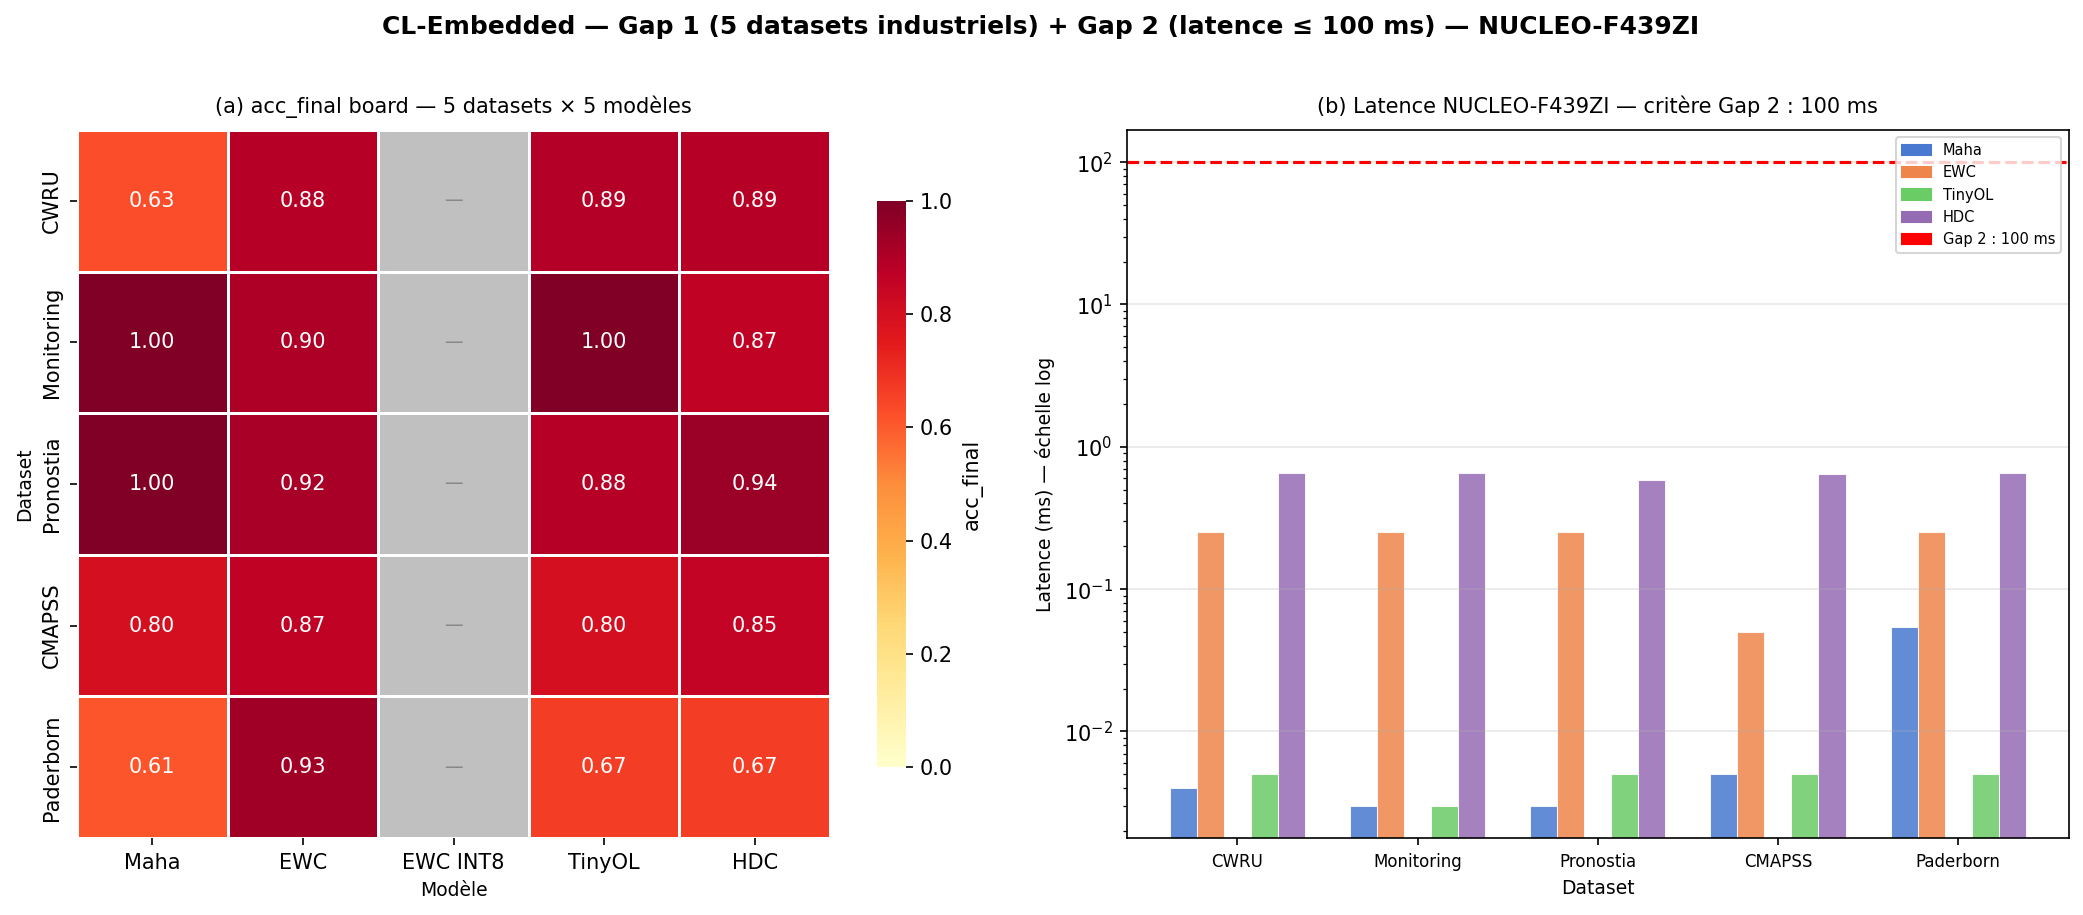

*Mesures de latence détaillées sur board*

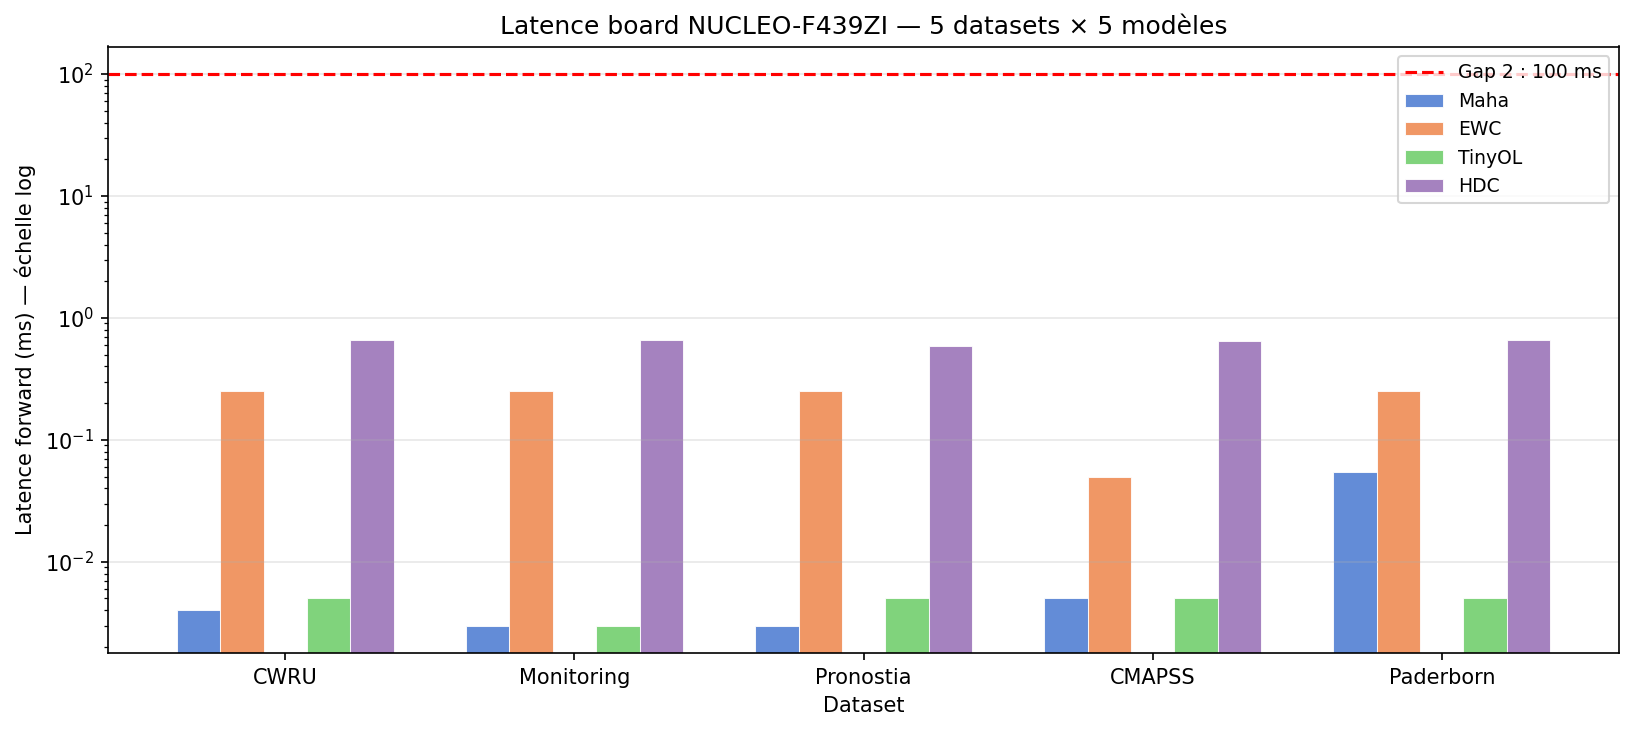

In [12]:
# Figures data-driven (source : notebooks/board_benchmark_all_datasets.ipynb ← comparison_sprint23.json)
show("gap1_gap2_summary.png", board=False, caption="Synthèse Gap 1 / Gap 2")
show("gap2_latency_board.png", board=False, caption="Mesures de latence détaillées sur board")

---
## Slide 13 — Perspectives
Réutilise la timeline (vue étendue Sprints 30-31).

*Timeline — perspectives Sprints 30-31 (paires de modèles + méta-modèle)*

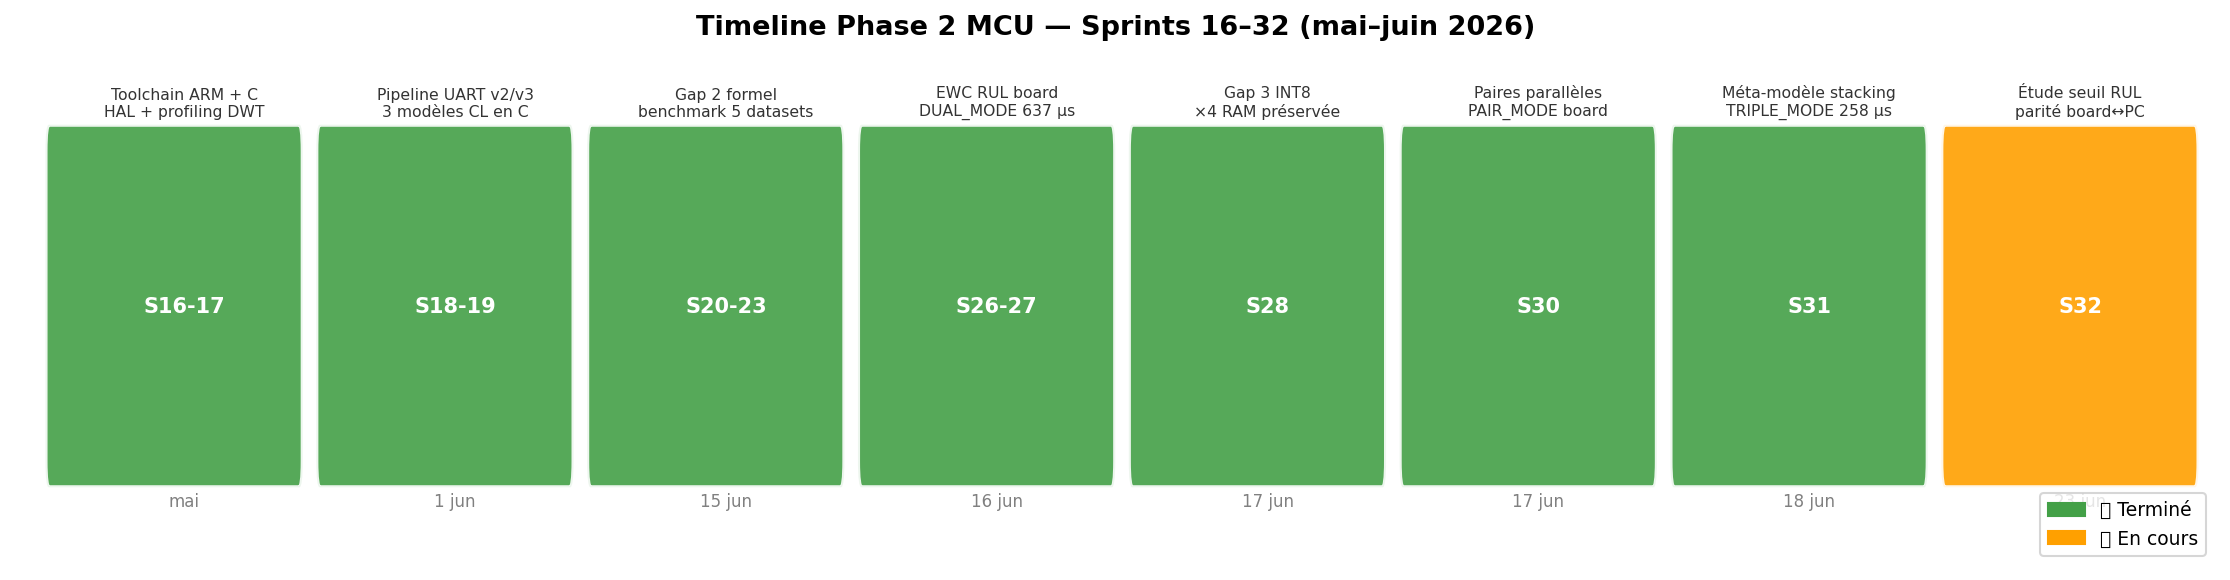

In [13]:
show("07_sprint_timeline.png", caption="Timeline — perspectives Sprints 30-31 (paires de modèles + méta-modèle)")

---
## Annexe — Figures complémentaires (slides de secours / Q&R)
Non utilisées dans le déroulé principal, gardées pour répondre aux questions.

*Synthèse Gap 1 / Gap 2*

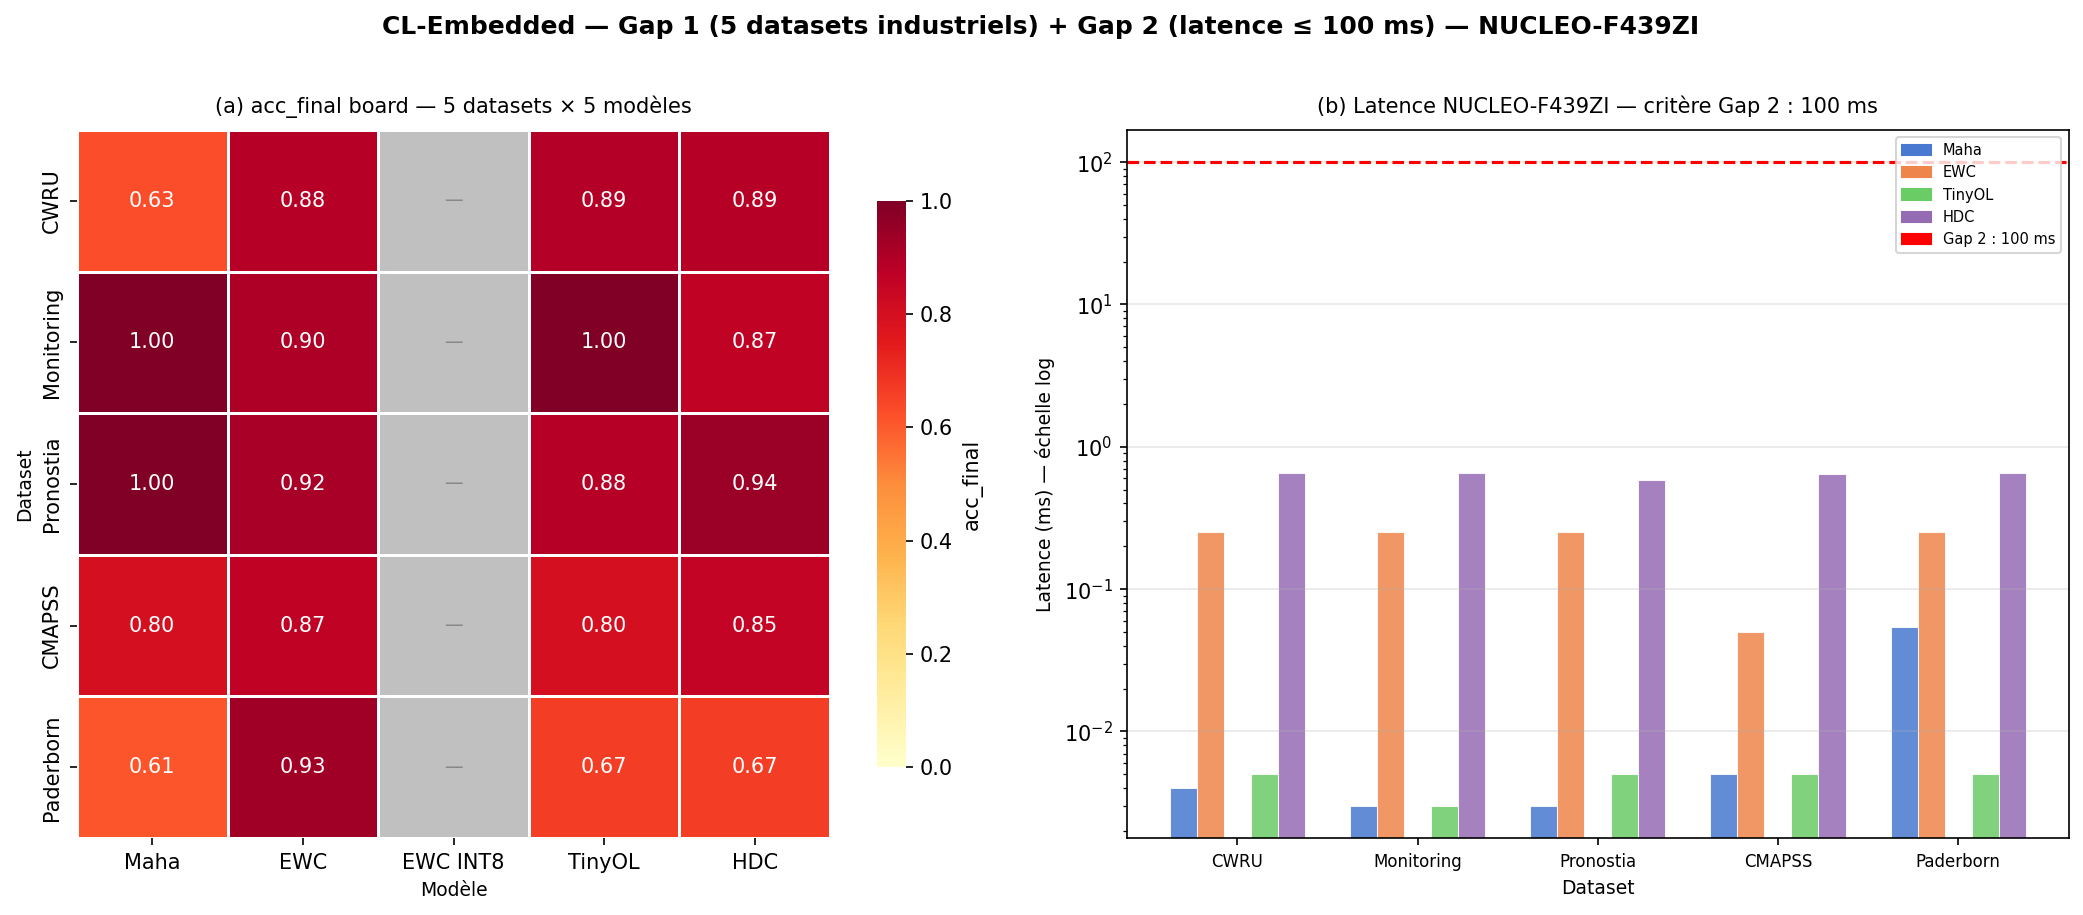

*Mesures de latence détaillées sur board*

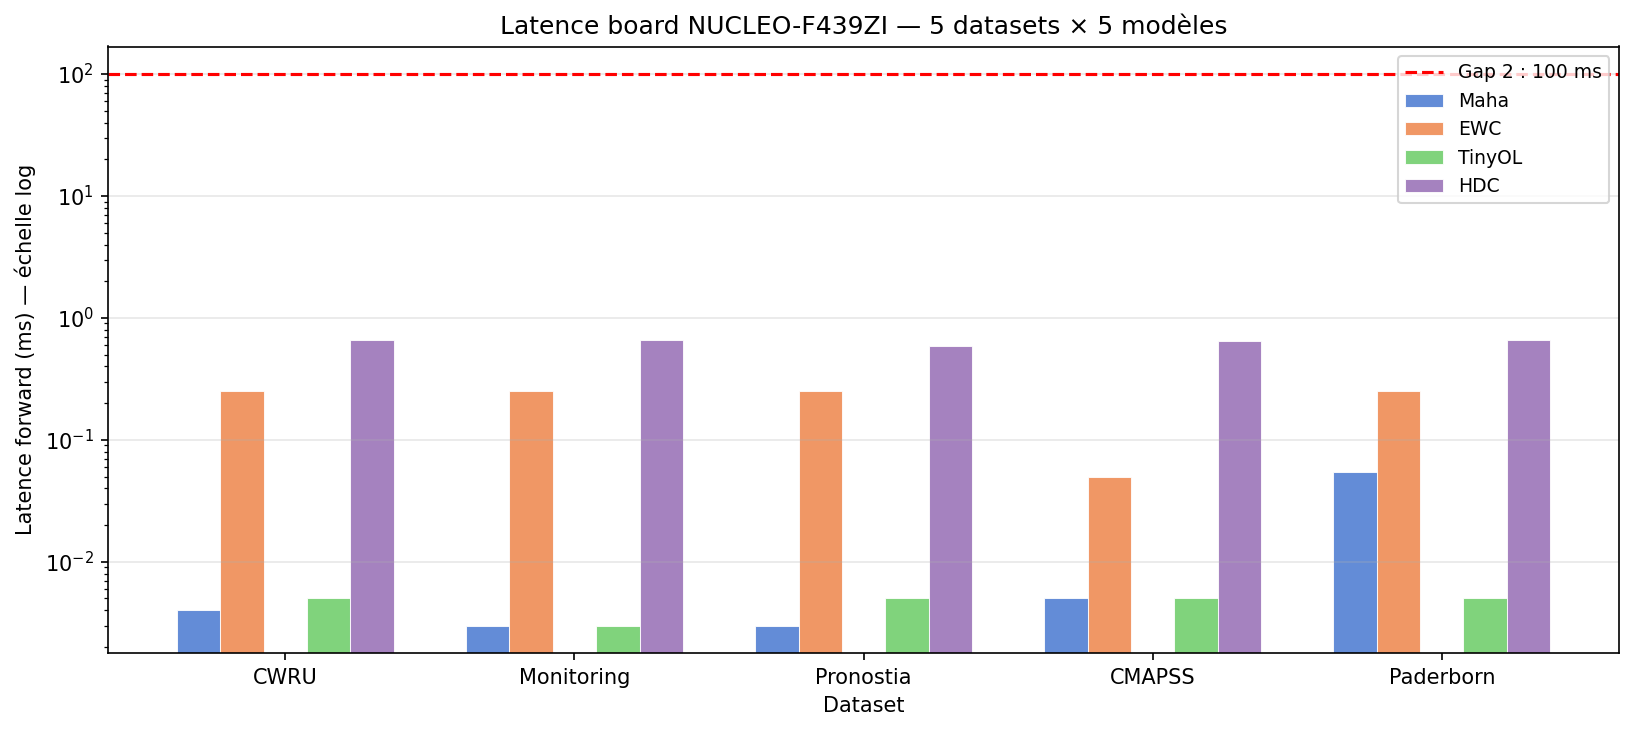

In [14]:
show("gap1_gap2_summary.png", board=False, caption="Synthèse Gap 1 / Gap 2")
show("gap2_latency_board.png", board=False, caption="Mesures de latence détaillées sur board")